In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

PROCESSED_DATA = Path("../data/processed")

pd.set_option("display.max_columns", None)

In [3]:
dim_candidato = pd.read_parquet(
    PROCESSED_DATA / "dim_candidato.parquet"
)

dim_partido = pd.read_parquet(
    PROCESSED_DATA / "dim_partido.parquet"
)

dim_cargo = pd.read_parquet(
    PROCESSED_DATA / "dim_cargo.parquet"
)

dim_estado = pd.read_parquet(
    PROCESSED_DATA / "dim_estado.parquet"
)

fato_candidatura = pd.read_parquet(
    PROCESSED_DATA / "fato_candidatura.parquet"
)

In [4]:
dim_candidato.head()

,id_candidato,SQ_CANDIDATO,nome_candidato,nome_urna,idade,genero,cor_raca,ocupacao,escolaridade,estado_civil
0,1,10002532416,ADGICLEIA DOS SANTOS GUIMARÃES,DR.. KEL GUIMARÃES,35,FEMININO,PARDA,MÉDICO,SUPERIOR COMPLETO,CASADO(A)
1,2,10002532417,FÁBIO DE ARAÚJO FREITAS,FÁBIO ARAÚJO,45,MASCULINO,PARDA,VEREADOR,SUPERIOR COMPLETO,CASADO(A)
2,3,10002532418,JOZINEY ALVES AMORIM,NEY AMORIM,49,MASCULINO,BRANCA,EMPRESÁRIO,SUPERIOR COMPLETO,CASADO(A)
3,4,10002532419,ANTÔNIA LUCILEIA CRUZ RAMOS CÂMARA,ANTÔNIA LÚCIA,56,FEMININO,PARDA,DEPUTADO,SUPERIOR COMPLETO,DIVORCIADO(A)
4,5,10002532420,MINORU MARTINS KINPARA,MINORU KINPARA,57,MASCULINO,PARDA,PROFESSOR DE ENSINO SUPERIOR,SUPERIOR COMPLETO,CASADO(A)


In [ ]:
# Análise Exploratória das Eleições 2026

Este notebook apresenta uma análise exploratória dos dados eleitorais,
buscando identificar padrões relacionados ao perfil dos candidatos,
distribuição partidária, cargos disputados e características
sociodemográficas.

In [5]:
print("Dimensão das tabelas")

print("Dim candidato:", dim_candidato.shape)
print("Dim partido:", dim_partido.shape)
print("Dim cargo:", dim_cargo.shape)
print("Dim estado:", dim_estado.shape)
print("Fato candidatura:", fato_candidatura.shape)

Dimensão das tabelas
Dim candidato: (20721, 10)
Dim partido: (30, 6)
Dim cargo: (10, 4)
Dim estado: (27, 3)
Fato candidatura: (20695, 6)


In [6]:
total_candidatos = dim_candidato["id_candidato"].nunique()

print(
    f"Total de candidatos: {total_candidatos:,}"
)

Total de candidatos: 20,721


In [7]:
total_partidos = dim_partido["id_partido"].nunique()

print(
    f"Total de partidos: {total_partidos}"
)

Total de partidos: 30


In [8]:
total_cargos = dim_cargo["id_cargo"].nunique()

print(
    f"Total de cargos: {total_cargos}"
)

Total de cargos: 10


In [9]:
total_estados = dim_estado["id_estado"].nunique()

print(
    f"Estados analisados: {total_estados}"
)

Estados analisados: 27


In [10]:
resumo = pd.DataFrame({
    "Indicador": [
        "Candidatos",
        "Partidos",
        "Cargos",
        "Estados"
    ],
    "Quantidade": [
        total_candidatos,
        total_partidos,
        total_cargos,
        total_estados
    ]
})

resumo

,Indicador,Quantidade
0,Candidatos,20721
1,Partidos,30
2,Cargos,10
3,Estados,27


In [ ]:
## 2. Perfil dos candidatos

In [11]:
genero = (
    dim_candidato["genero"]
    .value_counts()
    .reset_index()
)

genero.columns = [
    "Genero",
    "Quantidade"
]

genero

,Genero,Quantidade
0,MASCULINO,13492
1,FEMININO,7229


In [12]:
genero["Percentual"] = (
    genero["Quantidade"] /
    genero["Quantidade"].sum()
    * 100
)

genero

,Genero,Quantidade,Percentual
0,MASCULINO,13492,65.112688
1,FEMININO,7229,34.887312


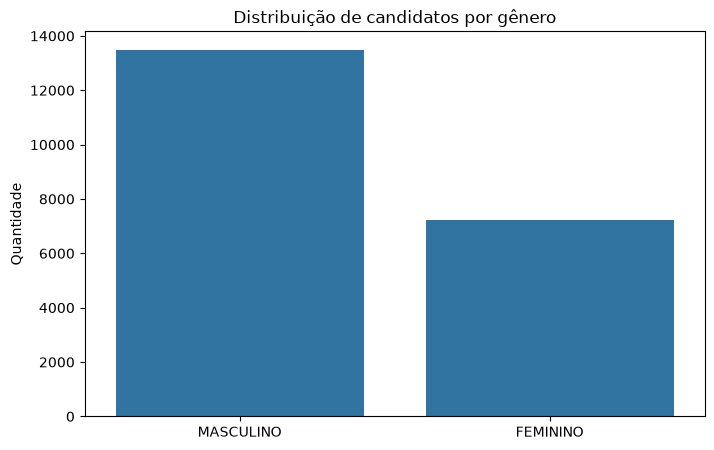

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=genero,
    x="Genero",
    y="Quantidade"
)

plt.title(
    "Distribuição de candidatos por gênero"
)

plt.xlabel("")
plt.ylabel("Quantidade")

plt.show()

In [ ]:
### Distribuição por raça/cor

In [14]:
raca = (
    dim_candidato["cor_raca"]
    .value_counts()
    .reset_index()
)

raca.columns = [
    "Cor_Raca",
    "Quantidade"
]

raca

,Cor_Raca,Quantidade
0,BRANCA,10281
1,PARDA,7320
2,PRETA,2818
3,INDÍGENA,194
4,AMARELA,108


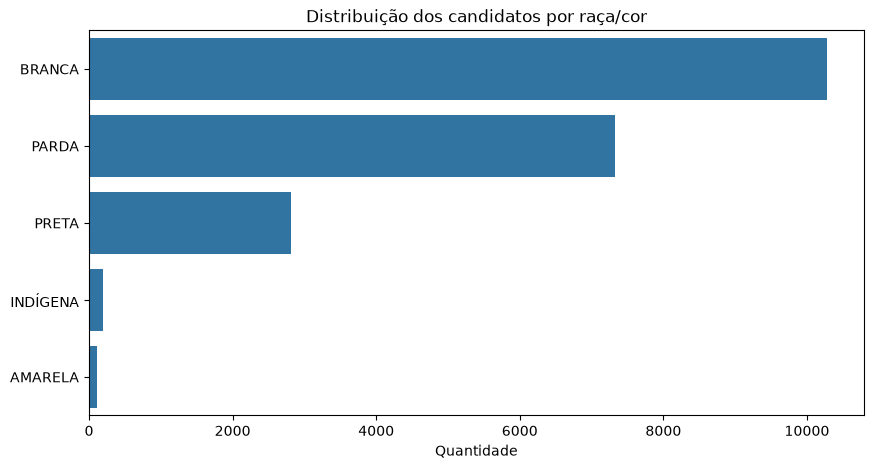

In [15]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=raca,
    x="Quantidade",
    y="Cor_Raca"
)

plt.title(
    "Distribuição dos candidatos por raça/cor"
)

plt.xlabel("Quantidade")
plt.ylabel("")

plt.show()

In [16]:
raca["Percentual"] = (
    raca["Quantidade"] /
    raca["Quantidade"].sum()
    * 100
)

raca

,Cor_Raca,Quantidade,Percentual
0,BRANCA,10281,49.616331
1,PARDA,7320,35.326480
2,PRETA,2818,13.599730
3,INDÍGENA,194,0.936248
4,AMARELA,108,0.521210


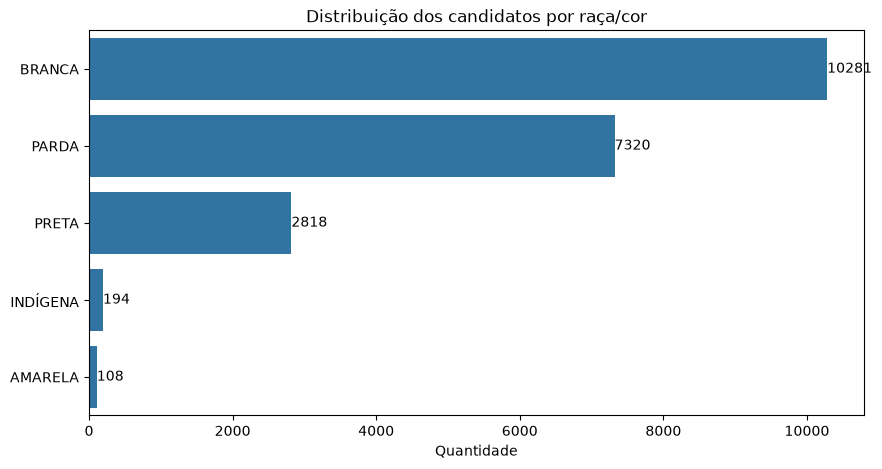

In [17]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=raca,
    x="Quantidade",
    y="Cor_Raca"
)

plt.title(
    "Distribuição dos candidatos por raça/cor"
)

plt.xlabel("Quantidade")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
### Distribuição de idade dos candidatos

In [18]:
dim_candidato["idade"].describe()

count    20721.000000
mean        49.232276
std         11.722576
min         19.000000
25%         41.000000
50%         49.000000
75%         57.000000
max         92.000000
Name: idade, dtype: float64

In [19]:
idade_media = dim_candidato["idade"].mean()

print(
    f"Idade média dos candidatos: {idade_media:.1f} anos"
)

Idade média dos candidatos: 49.2 anos


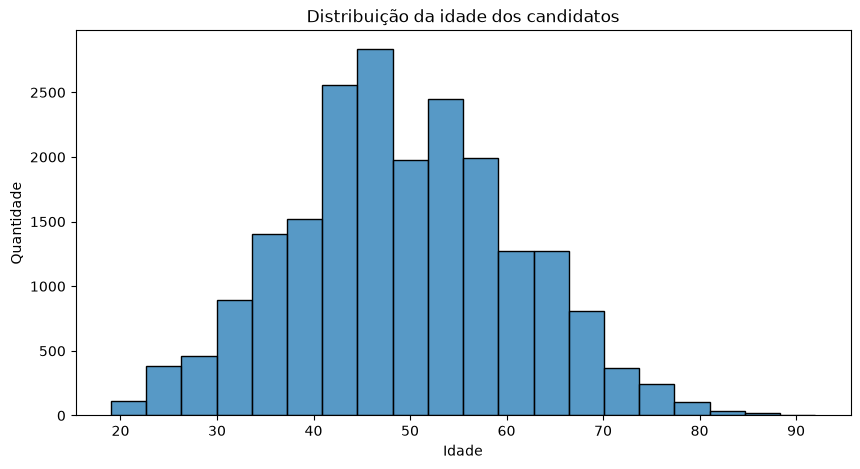

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=dim_candidato,
    x="idade",
    bins=20
)

plt.title(
    "Distribuição da idade dos candidatos"
)

plt.xlabel("Idade")
plt.ylabel("Quantidade")

plt.show()

In [ ]:
### Faixa etária dos candidatos

In [21]:
faixas = [
    18,
    30,
    40,
    50,
    60,
    70,
    100
]

labels = [
    "18-29",
    "30-39",
    "40-49",
    "50-59",
    "60-69",
    "70+"
]


dim_candidato["faixa_etaria"] = pd.cut(
    dim_candidato["idade"],
    bins=faixas,
    labels=labels
)


faixa_etaria = (
    dim_candidato["faixa_etaria"]
    .value_counts()
    .sort_index()
    .reset_index()
)

faixa_etaria.columns = [
    "Faixa",
    "Quantidade"
]

faixa_etaria

,Faixa,Quantidade
0,18-29,1163
1,30-39,3622
2,40-49,6759
3,50-59,5508
4,60-69,2892
5,70+,777


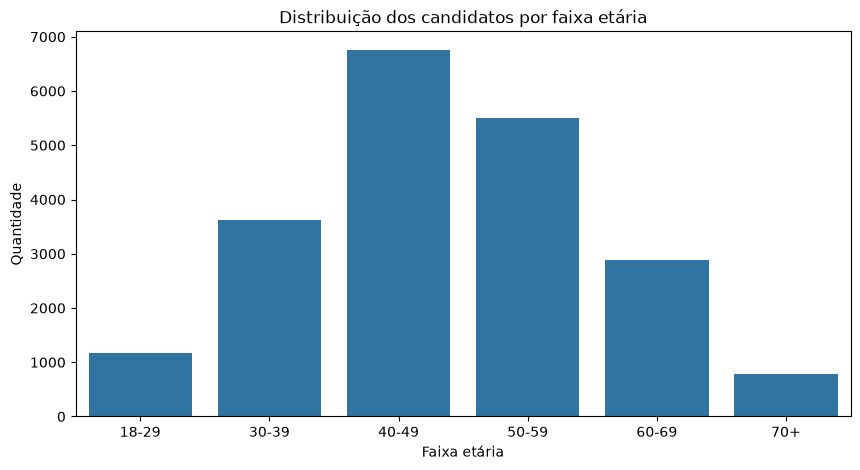

In [22]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=faixa_etaria,
    x="Faixa",
    y="Quantidade"
)

plt.title(
    "Distribuição dos candidatos por faixa etária"
)

plt.xlabel("Faixa etária")
plt.ylabel("Quantidade")

plt.show()

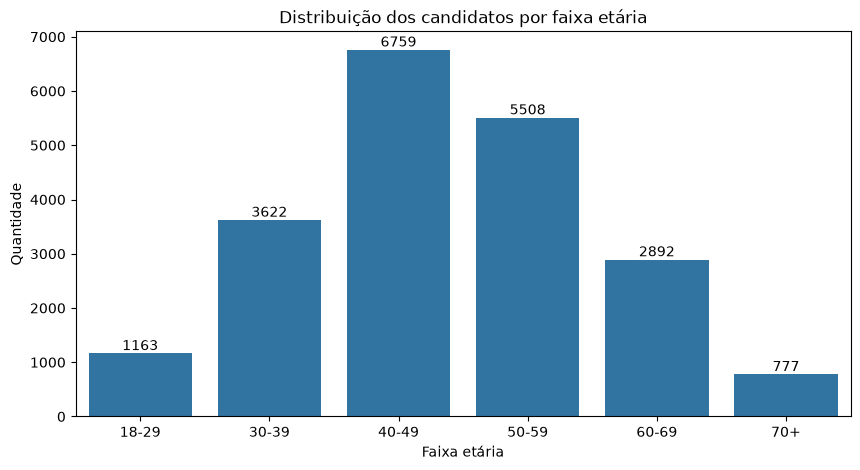

In [23]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=faixa_etaria,
    x="Faixa",
    y="Quantidade"
)

plt.title(
    "Distribuição dos candidatos por faixa etária"
)

plt.xlabel("Faixa etária")
plt.ylabel("Quantidade")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
### Escolaridade dos candidatos

In [24]:
escolaridade = (
    dim_candidato["escolaridade"]
    .value_counts()
    .reset_index()
)

escolaridade.columns = [
    "Escolaridade",
    "Quantidade"
]

escolaridade

,Escolaridade,Quantidade
0,SUPERIOR COMPLETO,12136
1,ENSINO MÉDIO COMPLETO,4447
2,SUPERIOR INCOMPLETO,2190
3,ENSINO MÉDIO INCOMPLETO,722
4,ENSINO FUNDAMENTAL INCOMPLETO,615
5,ENSINO FUNDAMENTAL COMPLETO,536
6,LÊ E ESCREVE,75


In [25]:
escolaridade["Percentual"] = (
    escolaridade["Quantidade"] /
    escolaridade["Quantidade"].sum()
    * 100
)

escolaridade

,Escolaridade,Quantidade,Percentual
0,SUPERIOR COMPLETO,12136,58.568602
1,ENSINO MÉDIO COMPLETO,4447,21.461319
2,SUPERIOR INCOMPLETO,2190,10.568988
3,ENSINO MÉDIO INCOMPLETO,722,3.484388
4,ENSINO FUNDAMENTAL INCOMPLETO,615,2.968003
5,ENSINO FUNDAMENTAL COMPLETO,536,2.586748
6,LÊ E ESCREVE,75,0.361952


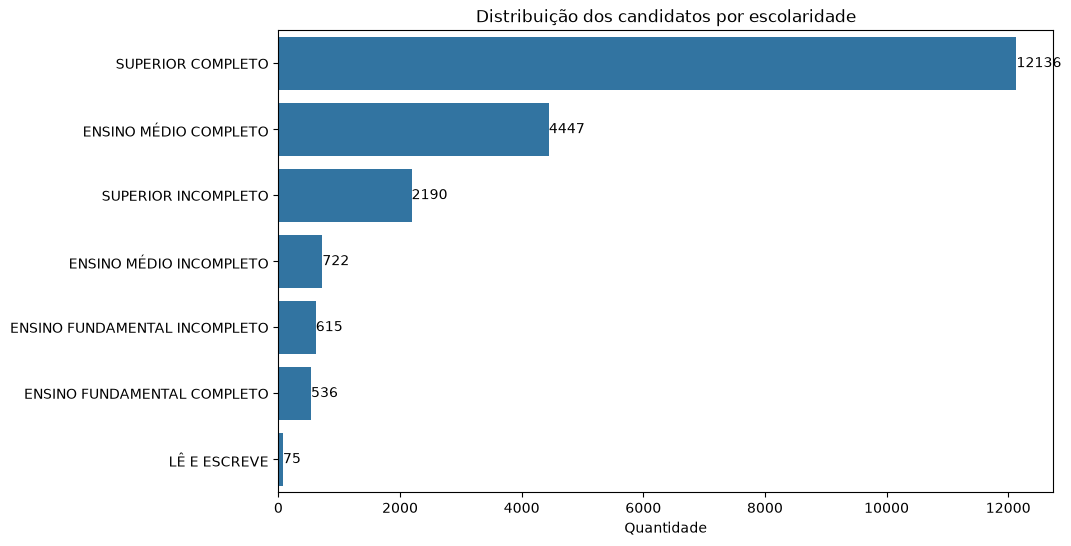

In [26]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=escolaridade,
    x="Quantidade",
    y="Escolaridade"
)

plt.title(
    "Distribuição dos candidatos por escolaridade"
)

plt.xlabel("Quantidade")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
### Ocupação dos candidatos

In [28]:
ocupacao = (
    dim_candidato["ocupacao"]
    .value_counts()
    .reset_index()
)

ocupacao.columns = [
    "Ocupacao",
    "Quantidade"
]

ocupacao.head(15)

,Ocupacao,Quantidade
0,OUTROS,2760
1,EMPRESÁRIO,2601
2,ADVOGADO,1703
3,DEPUTADO,877
4,VEREADOR,816
5,POLICIAL MILITAR,574
6,MÉDICO,564
7,COMERCIANTE,544
8,SERVIDOR PÚBLICO ESTADUAL,538
9,ADMINISTRADOR,525


In [29]:
ocupacao["Percentual"] = (
    ocupacao["Quantidade"] /
    ocupacao["Quantidade"].sum()
    * 100
)

ocupacao.head(15)

,Ocupacao,Quantidade,Percentual
0,OUTROS,2760,13.319820
1,EMPRESÁRIO,2601,12.552483
2,ADVOGADO,1703,8.218715
3,DEPUTADO,877,4.232421
4,VEREADOR,816,3.938034
5,POLICIAL MILITAR,574,2.770137
6,MÉDICO,564,2.721876
7,COMERCIANTE,544,2.625356
8,SERVIDOR PÚBLICO ESTADUAL,538,2.596400
9,ADMINISTRADOR,525,2.533662


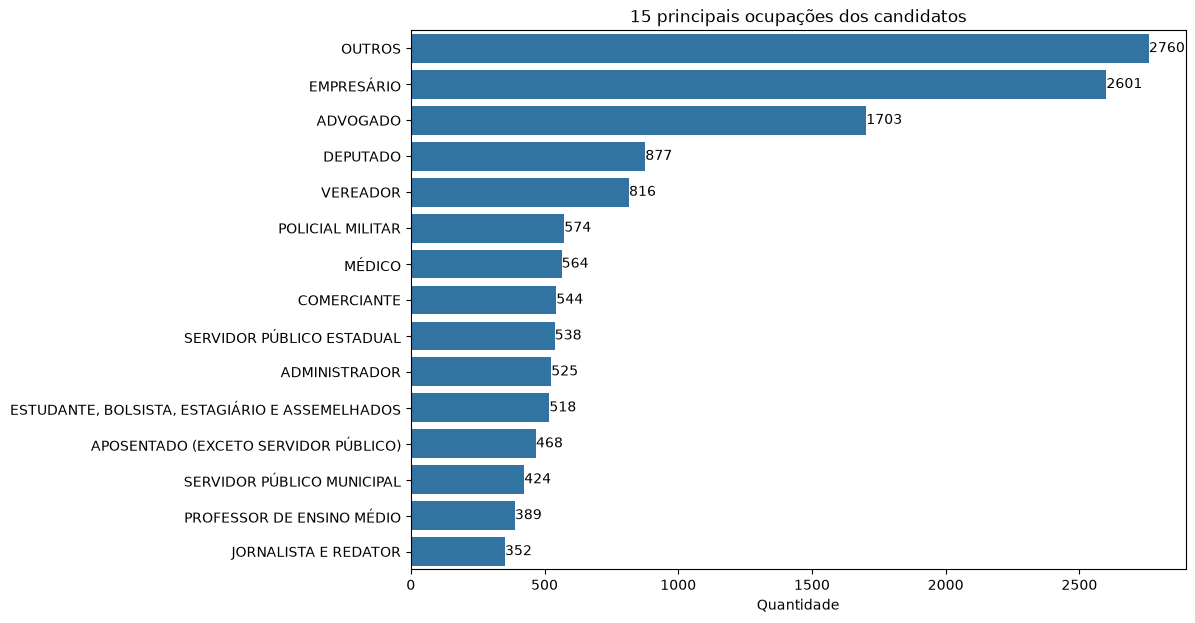

In [32]:
plt.figure(figsize=(10,7))

ax = sns.barplot(
    data=ocupacao.head(15),
    x="Quantidade",
    y="Ocupacao"
)

plt.title(
    "15 principais ocupações dos candidatos"
)

plt.xlabel("Quantidade")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [31]:
ocupacao.head(15)

,Ocupacao,Quantidade,Percentual
0,OUTROS,2760,13.319820
1,EMPRESÁRIO,2601,12.552483
2,ADVOGADO,1703,8.218715
3,DEPUTADO,877,4.232421
4,VEREADOR,816,3.938034
5,POLICIAL MILITAR,574,2.770137
6,MÉDICO,564,2.721876
7,COMERCIANTE,544,2.625356
8,SERVIDOR PÚBLICO ESTADUAL,538,2.596400
9,ADMINISTRADOR,525,2.533662


In [ ]:
### Observações sobre ocupação dos candidatos

A análise das ocupações revela uma concentração de candidatos provenientes
de grupos profissionais tradicionalmente associados à atuação pública,
empresarial e institucional.

A categoria "Outros" apresenta a maior frequência, indicando a existência
de diversas ocupações com menor representação individual.

Entre as ocupações específicas, destacam-se empresários, advogados e
ocupações relacionadas diretamente à política, como deputados e vereadores.

In [ ]:
## 3. Distribuição partidária dos candidatos

In [33]:
partidos = (
    fato_candidatura
    .merge(
        dim_partido[["id_partido", "partido"]],
        on="id_partido",
        how="left"
    )
)

partidos = (
    partidos["partido"]
    .value_counts()
    .reset_index()
)

partidos.columns = [
    "Partido",
    "Quantidade"
]

partidos.head(15)

,Partido,Quantidade
0,PL,1633
1,MDB,1407
2,REPUBLICANOS,1300
3,NOVO,1291
4,PODE,1229
5,PSD,1124
6,PDT,1106
7,PT,1101
8,PSDB,1068
9,AVANTE,970


In [34]:
partidos["Percentual"] = (
    partidos["Quantidade"] /
    partidos["Quantidade"].sum()
    *100
)

partidos.head(15)

,Partido,Quantidade,Percentual
0,PL,1633,7.890795
1,MDB,1407,6.798744
2,REPUBLICANOS,1300,6.281711
3,NOVO,1291,6.238222
4,PODE,1229,5.938633
5,PSD,1124,5.431264
6,PDT,1106,5.344286
7,PT,1101,5.320126
8,PSDB,1068,5.160667
9,AVANTE,970,4.687122


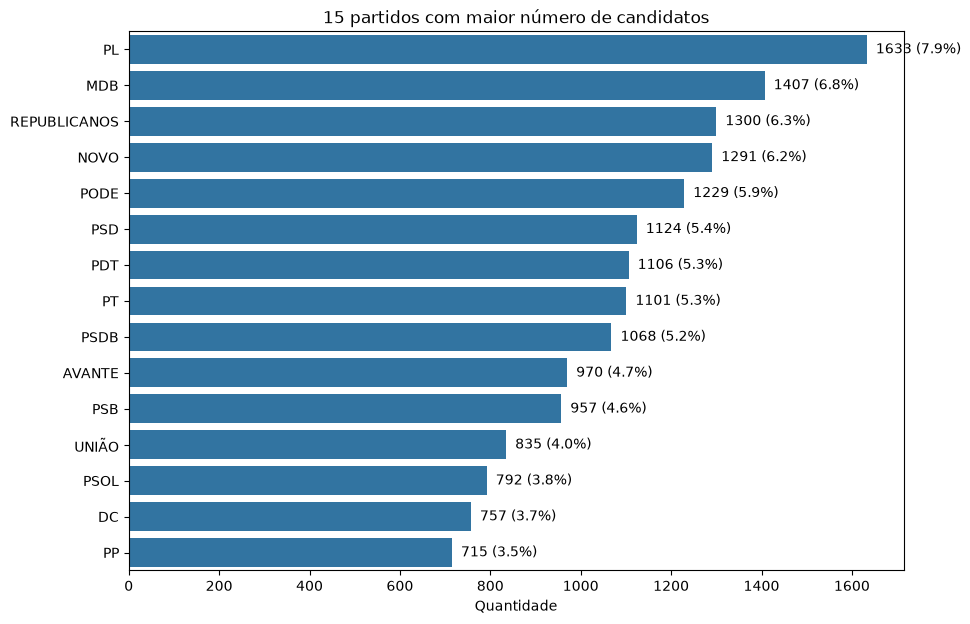

In [36]:
plt.figure(figsize=(10,7))

ax = sns.barplot(
    data=partidos.head(15),
    x="Quantidade",
    y="Partido"
)

plt.title(
    "15 partidos com maior número de candidatos"
)

plt.xlabel("Quantidade")
plt.ylabel("")

for i, row in partidos.head(15).reset_index().iterrows():
    ax.text(
        row["Quantidade"] + 20,
        i,
        f'{row["Quantidade"]} ({row["Percentual"]:.1f}%)',
        va="center"
    )

plt.show()

In [ ]:
### Observações sobre a distribuição partidária

A análise da distribuição partidária evidencia um cenário eleitoral
diversificado, com 30 partidos representados na base analisada.

O Partido Liberal (PL) apresentou o maior número de candidatos,
com 1.633 candidaturas, correspondendo a aproximadamente 7,9% do total.

Apesar da liderança do PL, observa-se que nenhum partido concentra
individualmente uma parcela dominante das candidaturas, indicando uma
distribuição relativamente pulverizada entre diferentes legendas.

In [37]:
cargo = (
    fato_candidatura
    .merge(
        dim_cargo[["id_cargo", "cargo"]],
        on="id_cargo",
        how="left"
    )
)

cargo = (
    cargo["cargo"]
    .value_counts()
    .reset_index()
)

cargo.columns = [
    "Cargo",
    "Quantidade"
]

cargo

,Cargo,Quantidade
0,DEPUTADO ESTADUAL,11191
1,DEPUTADO FEDERAL,7707
2,DEPUTADO DISTRITAL,429
3,2º SUPLENTE,328
4,1º SUPLENTE,325
5,SENADOR,316
6,VICE-GOVERNADOR,201
7,GOVERNADOR,198


In [ ]:
### Observações sobre os cargos disputados

A distribuição dos candidatos evidencia uma forte concentração em cargos
legislativos. Os cargos de Deputado Estadual, Deputado Federal e Deputado
Distrital concentram aproximadamente 93% das candidaturas analisadas.

Em contraste, cargos majoritários como Governador, Vice-Governador e Senador
apresentam menor quantidade de candidatos devido à característica do sistema
eleitoral, que possui menor número de vagas disponíveis.

In [39]:
cargo["Percentual"] = (
    cargo["Quantidade"] /
    cargo["Quantidade"].sum()
    * 100
)

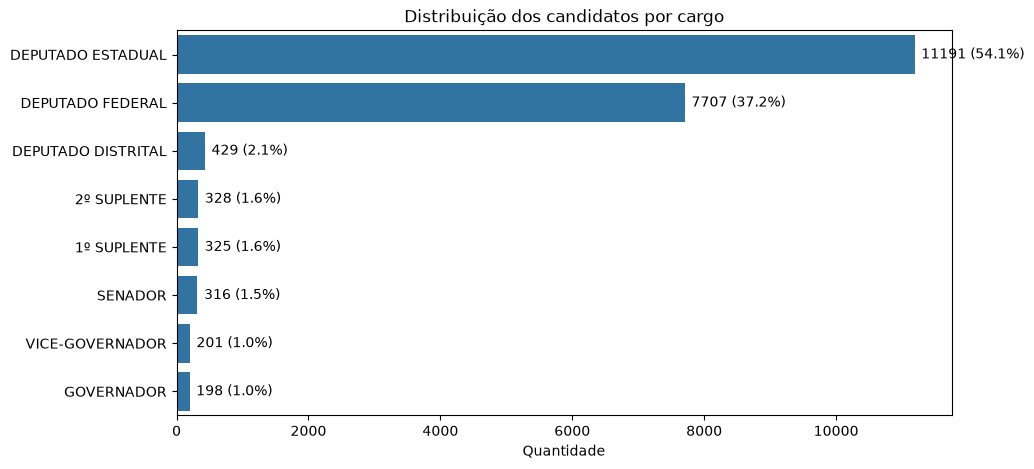

In [40]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=cargo,
    x="Quantidade",
    y="Cargo"
)

plt.title(
    "Distribuição dos candidatos por cargo"
)

plt.xlabel("Quantidade")
plt.ylabel("")

for i, row in cargo.iterrows():
    ax.text(
        row["Quantidade"] + 100,
        i,
        f'{row["Quantidade"]} ({row["Percentual"]:.1f}%)',
        va="center"
    )

plt.show()

In [ ]:
### Observações sobre a distribuição dos cargos

A distribuição das candidaturas apresenta forte concentração em cargos
legislativos. Os cargos de Deputado Estadual, Deputado Federal e Deputado
Distrital representam aproximadamente 93% das candidaturas analisadas.

Esse comportamento é esperado devido ao maior número de vagas disponíveis
nas eleições proporcionais, quando comparado aos cargos majoritários, como
Governador e Senador.

Os cargos majoritários apresentam menor quantidade de candidatos, refletindo
a menor disponibilidade de vagas e a dinâmica específica desse tipo de eleição.

In [46]:
analise_genero_cargo = (
    fato_candidatura
    .merge(
        dim_candidato[
            [
                "SQ_CANDIDATO",
                "genero"
            ]
        ],
        on="SQ_CANDIDATO",
        how="left"
    )
    .merge(
        dim_cargo[
            [
                "id_cargo",
                "cargo"
            ]
        ],
        on="id_cargo",
        how="left"
    )
)


analise_genero_cargo.head()

,SQ_CANDIDATO,id_partido,id_cargo,id_estado,ANO_ELEICAO,situacao_final,genero,cargo
0,260002551550,3,5,25.0,2026,Não informado,MASCULINO,SENADOR
1,90002547105,24,6,9.0,2026,Não informado,FEMININO,DEPUTADO FEDERAL
2,90002547109,24,6,9.0,2026,Não informado,MASCULINO,DEPUTADO FEDERAL
3,250002553062,16,3,26.0,2026,Não informado,FEMININO,GOVERNADOR
4,40002551283,8,5,3.0,2026,Não informado,MASCULINO,SENADOR


In [47]:
analise_genero_cargo.shape

(20695, 8)

In [48]:
analise_genero_cargo.head()

,SQ_CANDIDATO,id_partido,id_cargo,id_estado,ANO_ELEICAO,situacao_final,genero,cargo
0,260002551550,3,5,25.0,2026,Não informado,MASCULINO,SENADOR
1,90002547105,24,6,9.0,2026,Não informado,FEMININO,DEPUTADO FEDERAL
2,90002547109,24,6,9.0,2026,Não informado,MASCULINO,DEPUTADO FEDERAL
3,250002553062,16,3,26.0,2026,Não informado,FEMININO,GOVERNADOR
4,40002551283,8,5,3.0,2026,Não informado,MASCULINO,SENADOR


In [49]:
genero_cargo = (
    analise_genero_cargo
    .groupby(
        [
            "cargo",
            "genero"
        ]
    )
    .size()
    .reset_index(
        name="Quantidade"
    )
)


genero_cargo

,cargo,genero,Quantidade
0,1º SUPLENTE,FEMININO,98
1,1º SUPLENTE,MASCULINO,227
2,2º SUPLENTE,FEMININO,102
3,2º SUPLENTE,MASCULINO,226
4,DEPUTADO DISTRITAL,FEMININO,151
5,DEPUTADO DISTRITAL,MASCULINO,278
6,DEPUTADO ESTADUAL,FEMININO,3861
7,DEPUTADO ESTADUAL,MASCULINO,7330
8,DEPUTADO FEDERAL,FEMININO,2821
9,DEPUTADO FEDERAL,MASCULINO,4886


In [50]:
genero_cargo["Percentual"] = (
    genero_cargo["Quantidade"] /
    genero_cargo.groupby("cargo")["Quantidade"]
    .transform("sum")
    * 100
)


genero_cargo

,cargo,genero,Quantidade,Percentual
0,1º SUPLENTE,FEMININO,98,30.153846
1,1º SUPLENTE,MASCULINO,227,69.846154
2,2º SUPLENTE,FEMININO,102,31.097561
3,2º SUPLENTE,MASCULINO,226,68.902439
4,DEPUTADO DISTRITAL,FEMININO,151,35.198135
5,DEPUTADO DISTRITAL,MASCULINO,278,64.801865
6,DEPUTADO ESTADUAL,FEMININO,3861,34.500938
7,DEPUTADO ESTADUAL,MASCULINO,7330,65.499062
8,DEPUTADO FEDERAL,FEMININO,2821,36.603088
9,DEPUTADO FEDERAL,MASCULINO,4886,63.396912


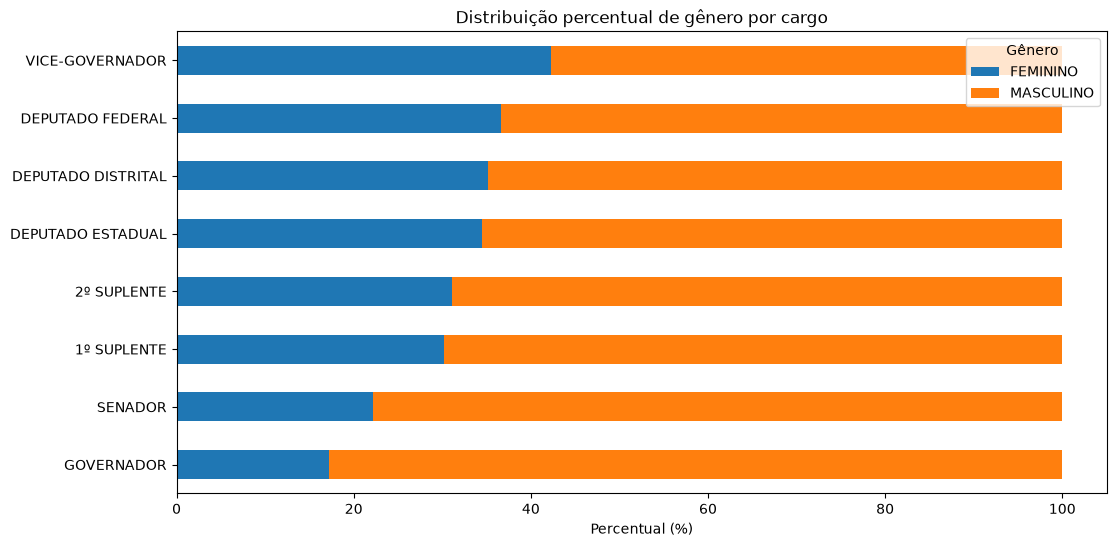

In [53]:
grafico = genero_cargo.pivot(
    index="cargo",
    columns="genero",
    values="Percentual"
)


grafico = grafico.sort_values(
    by="FEMININO"
)


grafico.plot(
    kind="barh",
    stacked=True,
    figsize=(12,6)
)


plt.title(
    "Distribuição percentual de gênero por cargo"
)

plt.xlabel(
    "Percentual (%)"
)

plt.ylabel("")


plt.legend(
    title="Gênero"
)

plt.show()

In [ ]:
### Observações sobre gênero e cargos

A análise cruzada entre gênero e cargo disputado evidencia uma predominância masculina em todas as categorias analisadas. Observa-se que essa diferença é mais acentuada nos cargos executivos, especialmente Governador e Senador, nos quais a participação feminina permanece inferior a 25%.

Entre os cargos legislativos, observa-se uma maior participação proporcional feminina, com valores próximos a 35% para Deputados Estaduais, Federais e Distritais. Apesar dessa maior representação relativa, ainda permanece uma predominância masculina nas candidaturas.

O cargo de Vice-Governador apresentou a maior participação proporcional feminina entre os cargos analisados, com aproximadamente 42% das candidaturas pertencentes ao gênero feminino.

In [57]:
dim_partido.columns

Index(['id_partido', 'NR_PARTIDO', 'partido', 'nome_partido', 'NR_FEDERACAO',
       'NM_FEDERACAO'],
      dtype='str')

In [59]:
analise_partido_genero = (
    fato_candidatura
    .merge(
        dim_candidato[
            [
                "SQ_CANDIDATO",
                "genero"
            ]
        ],
        on="SQ_CANDIDATO",
        how="left"
    )
    .merge(
        dim_partido[
            [
                "id_partido",
                "partido"
            ]
        ],
        on="id_partido",
        how="left"
    )
)

analise_partido_genero.head()

,SQ_CANDIDATO,id_partido,id_cargo,id_estado,ANO_ELEICAO,situacao_final,genero,partido
0,260002551550,3,5,25.0,2026,Não informado,MASCULINO,PDT
1,90002547105,24,6,9.0,2026,Não informado,FEMININO,PSDB
2,90002547109,24,6,9.0,2026,Não informado,MASCULINO,PSDB
3,250002553062,16,3,26.0,2026,Não informado,FEMININO,PCO
4,40002551283,8,5,3.0,2026,Não informado,MASCULINO,REDE


In [60]:
analise_partido_genero.shape

(20695, 8)

In [61]:
partido_genero = (
    analise_partido_genero
    .groupby(
        [
            "partido",
            "genero"
        ]
    )
    .size()
    .reset_index(name="Quantidade")
)

partido_genero.head()

,partido,genero,Quantidade
0,AGIR,FEMININO,147
1,AGIR,MASCULINO,312
2,AVANTE,FEMININO,321
3,AVANTE,MASCULINO,649
4,CIDADANIA,FEMININO,63


In [62]:
top_partidos = (
    analise_partido_genero["partido"]
    .value_counts()
    .head(15)
    .index
)

partido_genero_top = (
    partido_genero[
        partido_genero["partido"].isin(top_partidos)
    ]
)

partido_genero_top

,partido,genero,Quantidade
2,AVANTE,FEMININO,321
3,AVANTE,MASCULINO,649
6,DC,FEMININO,234
7,DC,MASCULINO,523
10,MDB,FEMININO,496
11,MDB,MASCULINO,911
16,NOVO,FEMININO,420
17,NOVO,MASCULINO,871
24,PDT,FEMININO,383
25,PDT,MASCULINO,723


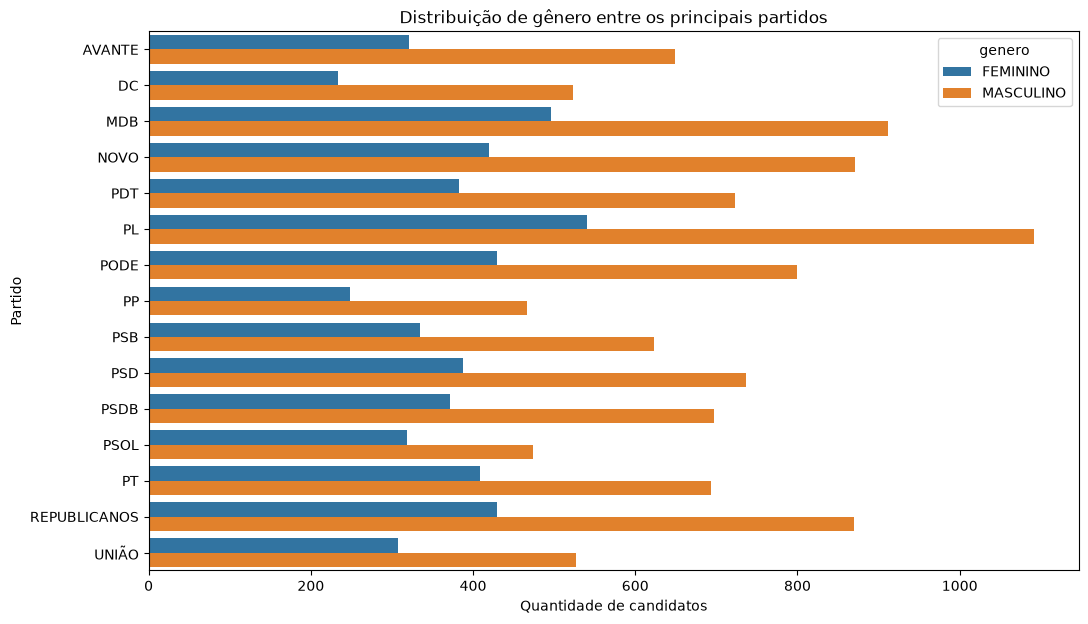

In [63]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=partido_genero_top,
    x="Quantidade",
    y="partido",
    hue="genero"
)

plt.title(
    "Distribuição de gênero entre os principais partidos"
)

plt.xlabel("Quantidade de candidatos")
plt.ylabel("Partido")

plt.show()

In [64]:
partido_genero_percentual = (
    partido_genero
    .groupby("partido")["Quantidade"]
    .transform(lambda x: x / x.sum() * 100)
)

partido_genero["Percentual"] = partido_genero_percentual

partido_genero.head()

,partido,genero,Quantidade,Percentual
0,AGIR,FEMININO,147,32.026144
1,AGIR,MASCULINO,312,67.973856
2,AVANTE,FEMININO,321,33.092784
3,AVANTE,MASCULINO,649,66.907216
4,CIDADANIA,FEMININO,63,42.857143


In [65]:
top15_partidos = (
    analise_partido_genero["partido"]
    .value_counts()
    .head(15)
    .index
)


partido_genero_percentual = (
    partido_genero[
        partido_genero["partido"].isin(top15_partidos)
    ]
)

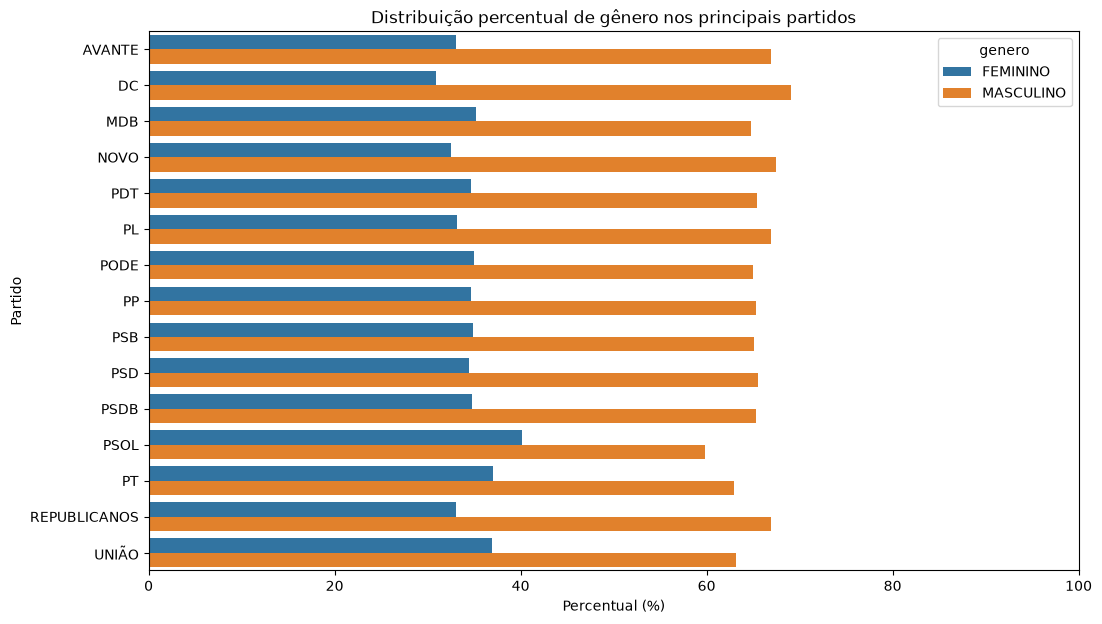

In [66]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=partido_genero_percentual,
    x="Percentual",
    y="partido",
    hue="genero"
)


plt.title(
    "Distribuição percentual de gênero nos principais partidos"
)

plt.xlabel("Percentual (%)")
plt.ylabel("Partido")


plt.xlim(0,100)

plt.show()

<Figure size 1200x700 with 0 Axes>

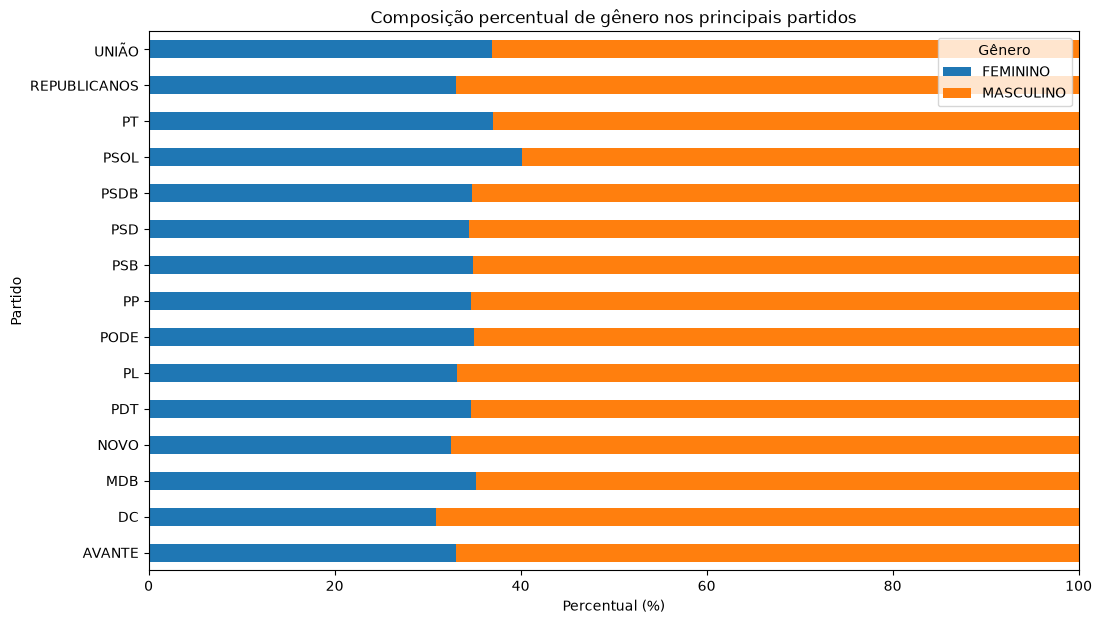

In [67]:
plt.figure(figsize=(12,7))

pivot_partido = (
    partido_genero_percentual
    .pivot(
        index="partido",
        columns="genero",
        values="Percentual"
    )
)

pivot_partido.plot(
    kind="barh",
    stacked=True,
    figsize=(12,7)
)

plt.title(
    "Composição percentual de gênero nos principais partidos"
)

plt.xlabel("Percentual (%)")
plt.ylabel("Partido")

plt.xlim(0,100)

plt.legend(
    title="Gênero"
)

plt.show()

In [ ]:
### Observações sobre gênero e partidos

A análise cruzada entre partido e gênero evidencia predominância masculina na composição das candidaturas em todas as principais legendas analisadas. Entretanto, observa-se variação na participação proporcional feminina entre os partidos.

O PSOL apresentou a maior proporção relativa de candidaturas femininas entre os partidos avaliados, seguido por PT e UNIÃO. Por outro lado, partidos como DC, NOVO e REPUBLICANOS apresentaram menores participações femininas proporcionais.

Os resultados indicam que, apesar das diferenças entre as legendas, a composição das candidaturas permanece majoritariamente masculina, evidenciando uma assimetria de representação de gênero no processo eleitoral.

In [68]:
analise_partido_cargo = (
    fato_candidatura
    .merge(
        dim_partido[
            [
                "id_partido",
                "partido"
            ]
        ],
        on="id_partido",
        how="left"
    )
    .merge(
        dim_cargo[
            [
                "id_cargo",
                "cargo"
            ]
        ],
        on="id_cargo",
        how="left"
    )
)


analise_partido_cargo.head()

,SQ_CANDIDATO,id_partido,id_cargo,id_estado,ANO_ELEICAO,situacao_final,partido,cargo
0,260002551550,3,5,25.0,2026,Não informado,PDT,SENADOR
1,90002547105,24,6,9.0,2026,Não informado,PSDB,DEPUTADO FEDERAL
2,90002547109,24,6,9.0,2026,Não informado,PSDB,DEPUTADO FEDERAL
3,250002553062,16,3,26.0,2026,Não informado,PCO,GOVERNADOR
4,40002551283,8,5,3.0,2026,Não informado,REDE,SENADOR


In [69]:
analise_partido_cargo.shape

(20695, 8)

In [70]:
partido_cargo = (
    analise_partido_cargo
    .groupby(
        [
            "partido",
            "cargo"
        ]
    )
    .size()
    .reset_index(name="Quantidade")
)


partido_cargo.head()

,partido,cargo,Quantidade
0,AGIR,1º SUPLENTE,9
1,AGIR,2º SUPLENTE,7
2,AGIR,DEPUTADO ESTADUAL,319
3,AGIR,DEPUTADO FEDERAL,103
4,AGIR,GOVERNADOR,7


In [71]:
top15_partidos = (
    analise_partido_cargo["partido"]
    .value_counts()
    .head(15)
    .index
)


partido_cargo_top = (
    partido_cargo[
        partido_cargo["partido"].isin(top15_partidos)
    ]
)


partido_cargo_top.head()

,partido,cargo,Quantidade
7,AVANTE,1º SUPLENTE,9
8,AVANTE,2º SUPLENTE,9
9,AVANTE,DEPUTADO DISTRITAL,26
10,AVANTE,DEPUTADO ESTADUAL,492
11,AVANTE,DEPUTADO FEDERAL,422


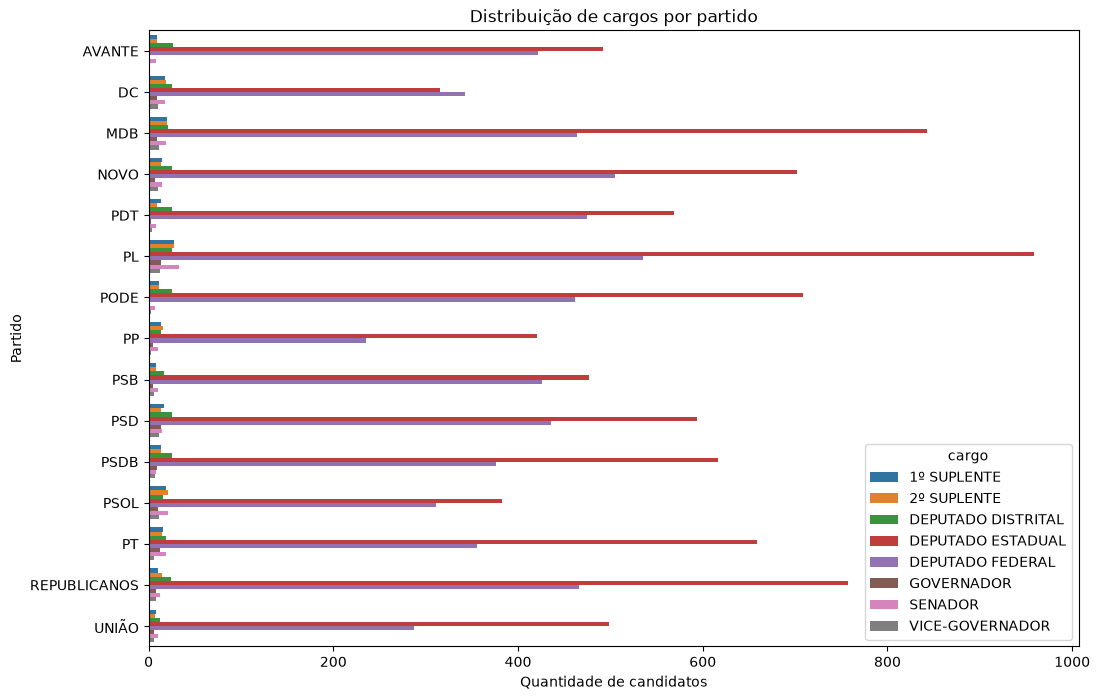

In [72]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=partido_cargo_top,
    x="Quantidade",
    y="partido",
    hue="cargo"
)


plt.title(
    "Distribuição de cargos por partido"
)

plt.xlabel(
    "Quantidade de candidatos"
)

plt.ylabel(
    "Partido"
)


plt.show()

In [73]:
matriz_partido_cargo = (
    partido_cargo_top
    .pivot(
        index="partido",
        columns="cargo",
        values="Quantidade"
    )
    .fillna(0)
)

matriz_partido_cargo

cargo,1º SUPLENTE,2º SUPLENTE,DEPUTADO DISTRITAL,DEPUTADO ESTADUAL,DEPUTADO FEDERAL,GOVERNADOR,SENADOR,VICE-GOVERNADOR
partido,,,,,,,,
AVANTE,9,9,26,492,422,2,8,2
DC,18,19,25,315,343,9,18,10
MDB,20,20,21,843,464,9,19,11
NOVO,15,13,25,702,505,7,14,10
PDT,13,9,25,569,475,3,8,4
PL,28,28,25,959,535,13,33,12
PODE,11,11,25,709,462,1,7,3
PP,13,16,13,420,235,5,10,3
PSB,8,8,17,477,426,5,10,6


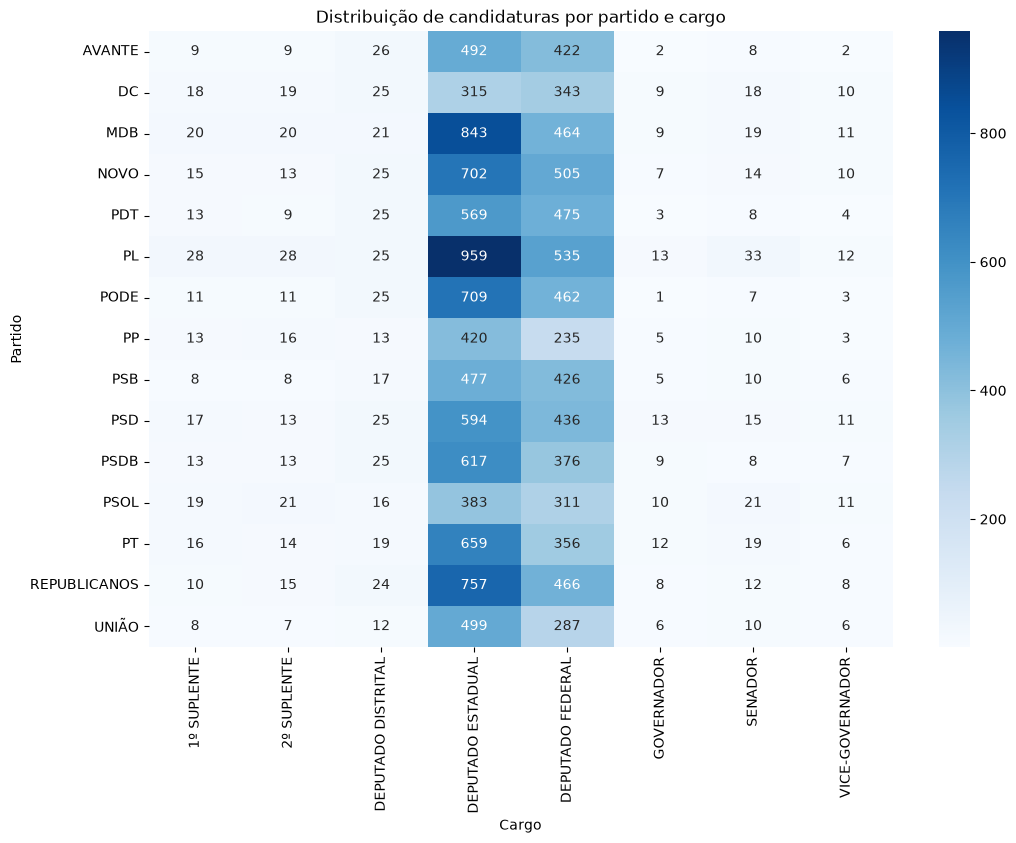

In [74]:
plt.figure(figsize=(12,8))

sns.heatmap(
    matriz_partido_cargo,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title(
    "Distribuição de candidaturas por partido e cargo"
)

plt.xlabel("Cargo")
plt.ylabel("Partido")

plt.show()

In [75]:
partido_cargo_percentual = (
    partido_cargo_top
    .assign(
        Percentual=lambda x:
        x.groupby("partido")["Quantidade"]
        .transform(lambda y: y/y.sum()*100)
    )
)

partido_cargo_percentual.head()

,partido,cargo,Quantidade,Percentual
7,AVANTE,1º SUPLENTE,9,0.927835
8,AVANTE,2º SUPLENTE,9,0.927835
9,AVANTE,DEPUTADO DISTRITAL,26,2.680412
10,AVANTE,DEPUTADO ESTADUAL,492,50.721649
11,AVANTE,DEPUTADO FEDERAL,422,43.505155


In [76]:
dim_candidato.columns

Index(['id_candidato', 'SQ_CANDIDATO', 'nome_candidato', 'nome_urna', 'idade',
       'genero', 'cor_raca', 'ocupacao', 'escolaridade', 'estado_civil',
       'faixa_etaria'],
      dtype='str')

In [77]:
dim_cargo.columns

Index(['id_cargo', 'CD_CARGO', 'cargo', 'tipo_cargo'], dtype='str')

In [78]:
analise_escolaridade_cargo = (
    fato_candidatura
    .merge(
        dim_candidato[
            [
                "SQ_CANDIDATO",
                "escolaridade"
            ]
        ],
        on="SQ_CANDIDATO",
        how="left"
    )
    .merge(
        dim_cargo[
            [
                "id_cargo",
                "cargo"
            ]
        ],
        on="id_cargo",
        how="left"
    )
)

analise_escolaridade_cargo.head()

,SQ_CANDIDATO,id_partido,id_cargo,id_estado,ANO_ELEICAO,situacao_final,escolaridade,cargo
0,260002551550,3,5,25.0,2026,Não informado,SUPERIOR INCOMPLETO,SENADOR
1,90002547105,24,6,9.0,2026,Não informado,SUPERIOR COMPLETO,DEPUTADO FEDERAL
2,90002547109,24,6,9.0,2026,Não informado,SUPERIOR COMPLETO,DEPUTADO FEDERAL
3,250002553062,16,3,26.0,2026,Não informado,SUPERIOR INCOMPLETO,GOVERNADOR
4,40002551283,8,5,3.0,2026,Não informado,SUPERIOR COMPLETO,SENADOR


In [79]:
analise_escolaridade_cargo.shape

(20695, 8)

In [81]:
escolaridade_cargo["Percentual"] = (
    escolaridade_cargo["Quantidade"] /
    escolaridade_cargo.groupby("cargo")["Quantidade"].transform("sum")
    * 100
)

escolaridade_cargo.head()

,cargo,escolaridade,Quantidade,Percentual
0,1º SUPLENTE,ENSINO FUNDAMENTAL COMPLETO,8,2.461538
1,1º SUPLENTE,ENSINO FUNDAMENTAL INCOMPLETO,6,1.846154
2,1º SUPLENTE,ENSINO MÉDIO COMPLETO,41,12.615385
3,1º SUPLENTE,ENSINO MÉDIO INCOMPLETO,10,3.076923
4,1º SUPLENTE,LÊ E ESCREVE,3,0.923077


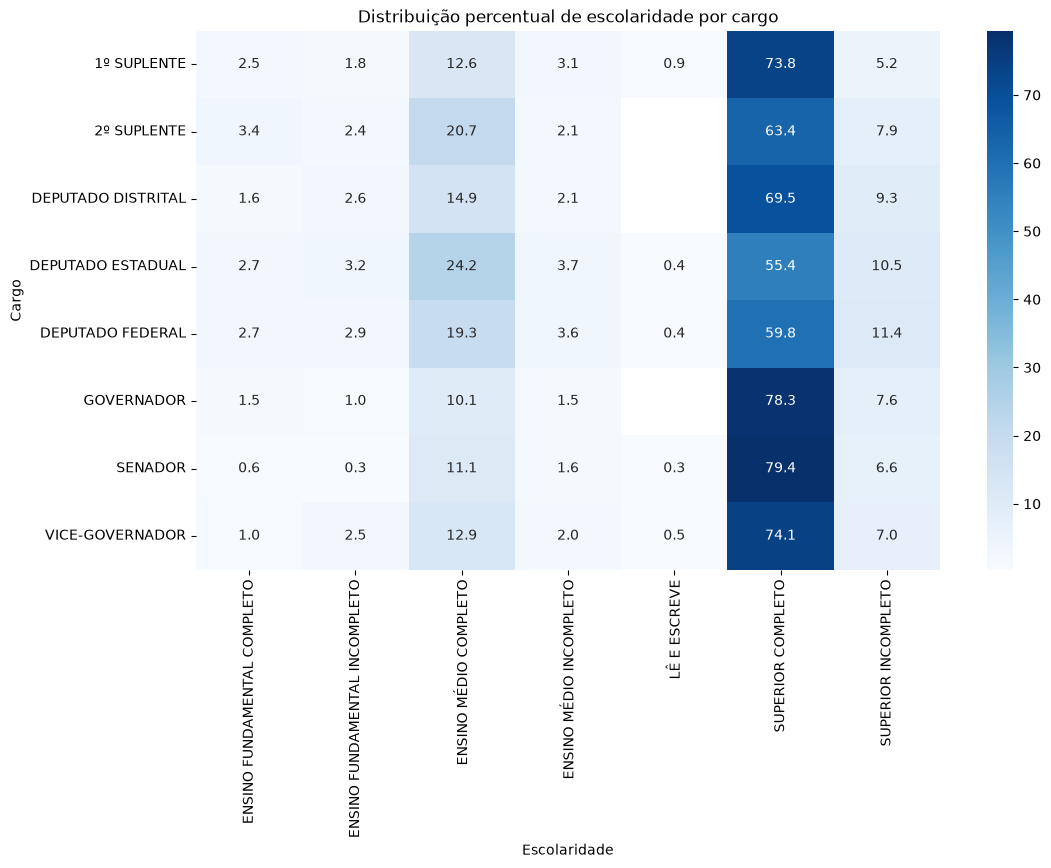

In [82]:
matriz_escolaridade_cargo = (
    escolaridade_cargo
    .pivot(
        index="cargo",
        columns="escolaridade",
        values="Percentual"
    )
)

plt.figure(figsize=(12,7))

sns.heatmap(
    matriz_escolaridade_cargo,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title(
    "Distribuição percentual de escolaridade por cargo"
)

plt.xlabel("Escolaridade")
plt.ylabel("Cargo")

plt.show()

In [ ]:
### Observações sobre escolaridade e cargos

A análise cruzada entre escolaridade e cargo evidencia uma forte predominância de candidatos com ensino superior completo em todas as categorias analisadas.

Os cargos majoritários apresentam os maiores percentuais de candidatos com formação superior, especialmente Senador e Governador, ambos com valores próximos a 80%.

Nos cargos legislativos observa-se maior diversidade educacional, embora o ensino superior completo continue sendo a principal categoria, representando aproximadamente 60% das candidaturas para Deputado Federal e 55% para Deputado Estadual.

Os resultados indicam uma associação entre cargos de maior projeção política e níveis mais elevados de escolaridade formal entre os candidatos.

In [86]:
ranking_partidos = (
    analise_partido_genero
    .groupby("partido")
    .size()
    .reset_index(name="Quantidade")
    .sort_values(
        "Quantidade",
        ascending=False
    )
)

ranking_partidos.head(15)

,partido,Quantidade
13,PL,1633
5,MDB,1407
26,REPUBLICANOS,1300
8,NOVO,1291
14,PODE,1229
19,PSD,1124
12,PDT,1106
23,PT,1101
20,PSDB,1068
1,AVANTE,970


In [87]:
ranking_partidos["Percentual"] = (
    ranking_partidos["Quantidade"]
    /
    ranking_partidos["Quantidade"].sum()
    *100
)

ranking_partidos["Acumulado"] = (
    ranking_partidos["Percentual"]
    .cumsum()
)

ranking_partidos.head(15)

,partido,Quantidade,Percentual,Acumulado
13,PL,1633,7.890795,7.890795
5,MDB,1407,6.798744,14.689539
26,REPUBLICANOS,1300,6.281711,20.971249
8,NOVO,1291,6.238222,27.209471
14,PODE,1229,5.938633,33.148103
19,PSD,1124,5.431264,38.579367
12,PDT,1106,5.344286,43.923653
23,PT,1101,5.320126,49.243779
20,PSDB,1068,5.160667,54.404446
1,AVANTE,970,4.687122,59.091568


In [85]:
candidatos_estado = (
    fato_candidatura
    .groupby("id_estado")
    .size()
    .reset_index(name="Quantidade")
)

candidatos_estado.sort_values(
    "Quantidade",
    ascending=False
)

,id_estado,Quantidade
25,26.0,2610
18,19.0,2024
10,11.0,1815
4,5.0,1217
17,18.0,1073
22,23.0,1051
15,16.0,957
8,9.0,894
13,14.0,724
5,6.0,708


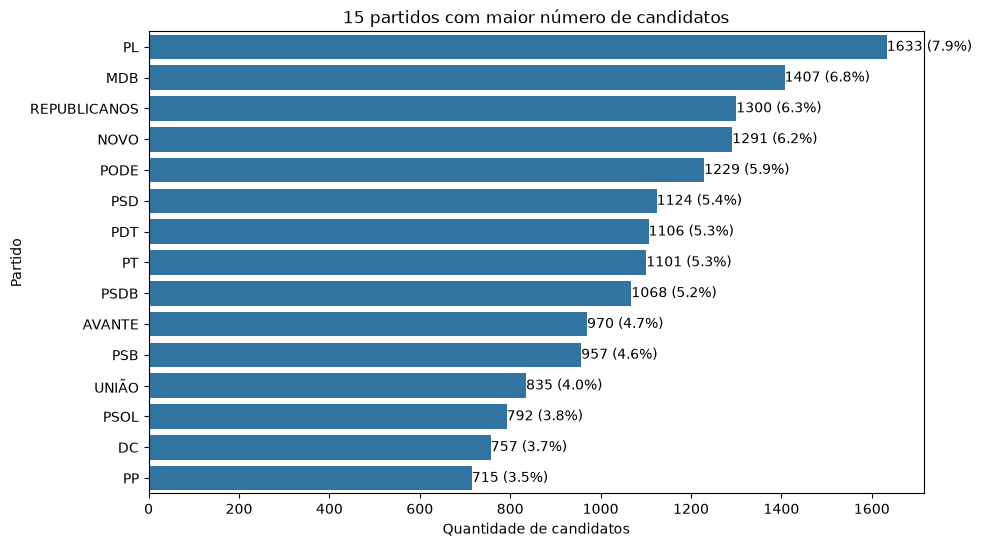

In [89]:
plt.figure(figsize=(10,6))

dados = ranking_partidos.head(15)

sns.barplot(
    data=dados,
    x="Quantidade",
    y="partido"
)

plt.title(
    "15 partidos com maior número de candidatos"
)

plt.xlabel(
    "Quantidade de candidatos"
)

plt.ylabel(
    "Partido"
)


for i, (valor, percentual) in enumerate(
    zip(
        dados["Quantidade"],
        dados["Percentual"]
    )
):
    plt.text(
        valor,
        i,
        f"{valor} ({percentual:.1f}%)",
        va="center"
    )

plt.show()

In [ ]:
## 5.1 Ranking dos partidos por número de candidaturas

A análise da quantidade de candidatos por partido permite identificar as legendas com maior participação na disputa eleitoral.

O PL apresenta o maior número de candidaturas, totalizando 1.633 candidatos (7,9%), seguido pelo MDB, com 1.407 candidatos (6,8%), e Republicanos, com 1.300 candidatos (6,3%). Apesar da liderança desses partidos, observa-se uma distribuição relativamente equilibrada entre as principais legendas, sem concentração elevada em uma única organização partidária.

Os 15 partidos com maior número de candidaturas concentram aproximadamente 78,7% do total analisado, demonstrando que uma parcela significativa da participação eleitoral está distribuída entre as principais siglas partidárias.

In [90]:
pareto_partidos = (
    ranking_partidos
    .copy()
)

pareto_partidos["Percentual_Acumulado"] = (
    pareto_partidos["Percentual"]
    .cumsum()
)

pareto_partidos.head(15)

,partido,Quantidade,Percentual,Acumulado,Percentual_Acumulado
13,PL,1633,7.890795,7.890795,7.890795
5,MDB,1407,6.798744,14.689539,14.689539
26,REPUBLICANOS,1300,6.281711,20.971249,20.971249
8,NOVO,1291,6.238222,27.209471,27.209471
14,PODE,1229,5.938633,33.148103,33.148103
19,PSD,1124,5.431264,38.579367,38.579367
12,PDT,1106,5.344286,43.923653,43.923653
23,PT,1101,5.320126,49.243779,49.243779
20,PSDB,1068,5.160667,54.404446,54.404446
1,AVANTE,970,4.687122,59.091568,59.091568


In [91]:
partidos_50 = (
    pareto_partidos[
        pareto_partidos["Percentual_Acumulado"] <= 50
    ]
)

partidos_80 = (
    pareto_partidos[
        pareto_partidos["Percentual_Acumulado"] <= 80
    ]
)

print(
    f"Quantidade de partidos para atingir 50%: {len(partidos_50)}"
)

print(
    f"Quantidade de partidos para atingir 80%: {len(partidos_80)}"
)

Quantidade de partidos para atingir 50%: 8
Quantidade de partidos para atingir 80%: 15


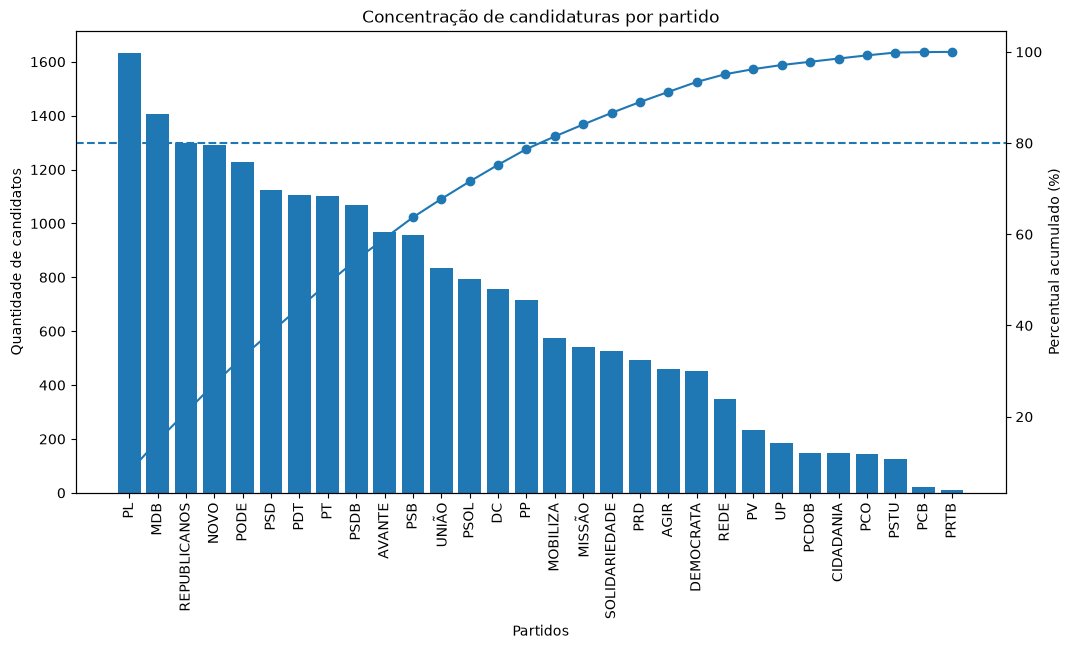

In [93]:
plt.figure(figsize=(12,6))

plt.bar(
    pareto_partidos["partido"],
    pareto_partidos["Quantidade"]
)

plt.xticks(rotation=90)

plt.ylabel("Quantidade de candidatos")
plt.xlabel("Partidos")

plt.title(
    "Concentração de candidaturas por partido"
)


ax2 = plt.twinx()

ax2.plot(
    pareto_partidos["partido"],
    pareto_partidos["Percentual_Acumulado"],
    marker="o"
)

ax2.set_ylabel(
    "Percentual acumulado (%)"
)

ax2.axhline(
    80,
    linestyle="--"
)


plt.show()

In [ ]:
## 5.2 Concentração partidária das candidaturas

A análise de concentração partidária permite avaliar se a distribuição das candidaturas está concentrada em poucas legendas ou distribuída entre diversos partidos.

Os resultados indicam que são necessários 8 partidos para alcançar aproximadamente 50% das candidaturas, enquanto 15 partidos representam cerca de 80% do total analisado. 

Embora o PL apresente a maior participação individual, com 7,9% das candidaturas, a distribuição geral demonstra baixa concentração partidária, evidenciando que a participação eleitoral está distribuída entre diferentes legendas.

In [94]:
dim_estado.columns

Index(['id_estado', 'estado', 'estado_nome'], dtype='str')

In [96]:
dim_candidato.columns

Index(['id_candidato', 'SQ_CANDIDATO', 'nome_candidato', 'nome_urna', 'idade',
       'genero', 'cor_raca', 'ocupacao', 'escolaridade', 'estado_civil',
       'faixa_etaria'],
      dtype='str')

In [97]:
fato_candidatura.columns

Index(['SQ_CANDIDATO', 'id_partido', 'id_cargo', 'id_estado', 'ANO_ELEICAO',
       'situacao_final'],
      dtype='str')

In [98]:
analise_estado = (
    fato_candidatura
    .merge(
        dim_estado[
            [
                "id_estado",
                "estado"
            ]
        ],
        on="id_estado",
        how="left"
    )
)

In [99]:
analise_estado.head()

,SQ_CANDIDATO,id_partido,id_cargo,id_estado,ANO_ELEICAO,situacao_final,estado
0,260002551550,3,5,25.0,2026,Não informado,SE
1,90002547105,24,6,9.0,2026,Não informado,GO
2,90002547109,24,6,9.0,2026,Não informado,GO
3,250002553062,16,3,26.0,2026,Não informado,SP
4,40002551283,8,5,3.0,2026,Não informado,AM


In [100]:
analise_estado.shape

(20695, 7)

In [101]:
ranking_estados = (
    analise_estado
    .groupby("estado")
    .size()
    .reset_index(name="Quantidade")
    .sort_values(
        "Quantidade",
        ascending=False
    )
)

ranking_estados["Percentual"] = (
    ranking_estados["Quantidade"]
    /
    ranking_estados["Quantidade"].sum()
    *100
)

ranking_estados

,estado,Quantidade,Percentual
25,SP,2610,12.611742
18,RJ,2024,9.780140
10,MG,1815,8.770234
4,BA,1217,5.880647
17,PR,1073,5.184827
22,RS,1051,5.078521
15,PE,957,4.624305
8,GO,894,4.319884
13,PA,724,3.498430
5,CE,708,3.421116


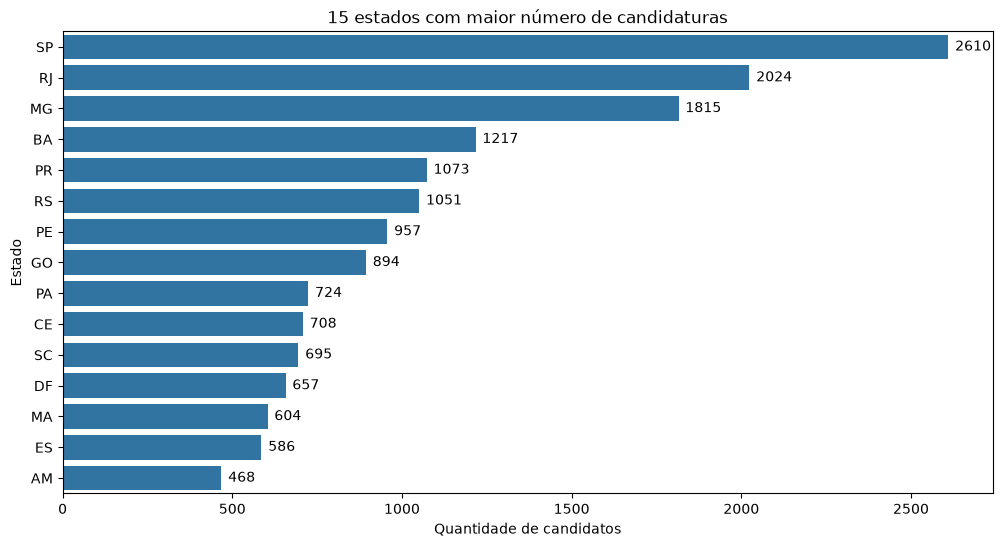

In [102]:
plt.figure(figsize=(12,6))

top_estados = (
    ranking_estados
    .head(15)
)

sns.barplot(
    data=top_estados,
    x="Quantidade",
    y="estado"
)

plt.title(
    "15 estados com maior número de candidaturas"
)

plt.xlabel(
    "Quantidade de candidatos"
)

plt.ylabel(
    "Estado"
)


for i, valor in enumerate(top_estados["Quantidade"]):
    plt.text(
        valor + 20,
        i,
        str(valor),
        va="center"
    )

plt.show()

In [103]:
pareto_estados = (
    ranking_estados
    .copy()
)

pareto_estados["Percentual_Acumulado"] = (
    pareto_estados["Percentual"]
    .cumsum()
)

pareto_estados.head()

,estado,Quantidade,Percentual,Percentual_Acumulado
25,SP,2610,12.611742,12.611742
18,RJ,2024,9.780140,22.391882
10,MG,1815,8.770234,31.162116
4,BA,1217,5.880647,37.042764
17,PR,1073,5.184827,42.227591


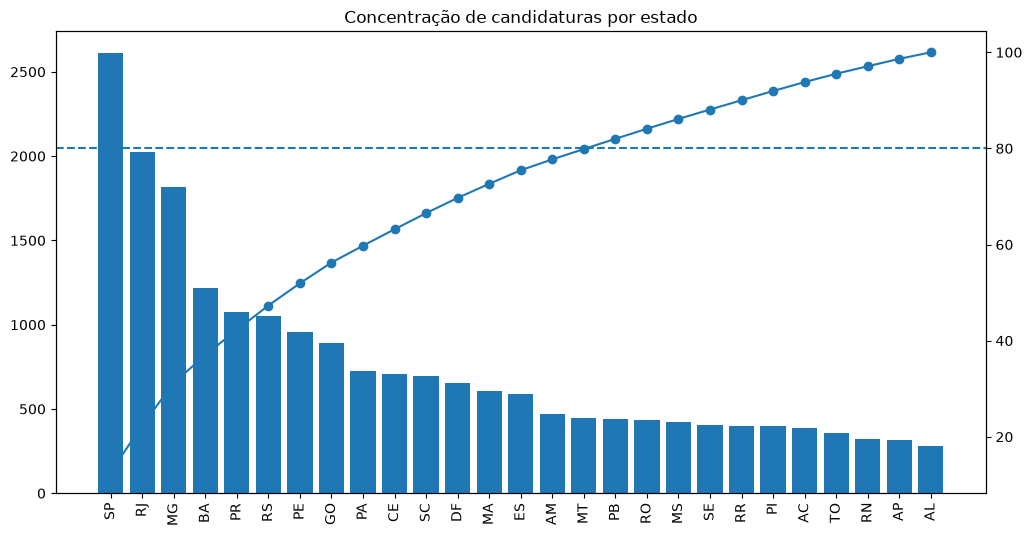

In [104]:
plt.figure(figsize=(12,6))

plt.bar(
    pareto_estados["estado"],
    pareto_estados["Quantidade"]
)

plt.xticks(rotation=90)

plt.twinx()

plt.plot(
    pareto_estados["estado"],
    pareto_estados["Percentual_Acumulado"],
    marker="o"
)

plt.axhline(
    80,
    linestyle="--"
)

plt.title(
    "Concentração de candidaturas por estado"
)

plt.show()

In [ ]:
## 5.3 Distribuição geográfica das candidaturas

A análise da distribuição das candidaturas por estado evidencia uma concentração relacionada ao tamanho populacional e à relevância eleitoral das unidades federativas.

São Paulo apresenta a maior quantidade de candidaturas, com 2.610 registros (12,6%), seguido por Rio de Janeiro (9,8%) e Minas Gerais (8,8%). Esses três estados concentram aproximadamente 31% das candidaturas analisadas.

Apesar da liderança dos estados mais populosos, a análise de concentração acumulada demonstra uma distribuição relativamente equilibrada entre as unidades federativas. São necessários cinco estados para concentrar cerca de 42% das candidaturas e aproximadamente quinze estados para ultrapassar 80% do total analisado.

Esse comportamento indica que a participação eleitoral apresenta menor concentração geográfica quando comparada à distribuição partidária, estando disseminada entre diferentes regiões do país.

In [105]:
analise_estado_cargo = (
    fato_candidatura
    .merge(
        dim_estado[
            [
                "id_estado",
                "estado"
            ]
        ],
        on="id_estado",
        how="left"
    )
    .merge(
        dim_cargo[
            [
                "id_cargo",
                "cargo"
            ]
        ],
        on="id_cargo",
        how="left"
    )
)

analise_estado_cargo.head()

,SQ_CANDIDATO,id_partido,id_cargo,id_estado,ANO_ELEICAO,situacao_final,estado,cargo
0,260002551550,3,5,25.0,2026,Não informado,SE,SENADOR
1,90002547105,24,6,9.0,2026,Não informado,GO,DEPUTADO FEDERAL
2,90002547109,24,6,9.0,2026,Não informado,GO,DEPUTADO FEDERAL
3,250002553062,16,3,26.0,2026,Não informado,SP,GOVERNADOR
4,40002551283,8,5,3.0,2026,Não informado,AM,SENADOR


In [106]:
analise_estado_cargo.shape

(20695, 8)

In [107]:
estado_cargo = (
    analise_estado_cargo
    .groupby(
        [
            "estado",
            "cargo"
        ]
    )
    .size()
    .reset_index(name="Quantidade")
)

estado_cargo.head()

,estado,cargo,Quantidade
0,AC,1º SUPLENTE,9
1,AC,2º SUPLENTE,9
2,AC,DEPUTADO ESTADUAL,245
3,AC,DEPUTADO FEDERAL,102
4,AC,GOVERNADOR,6


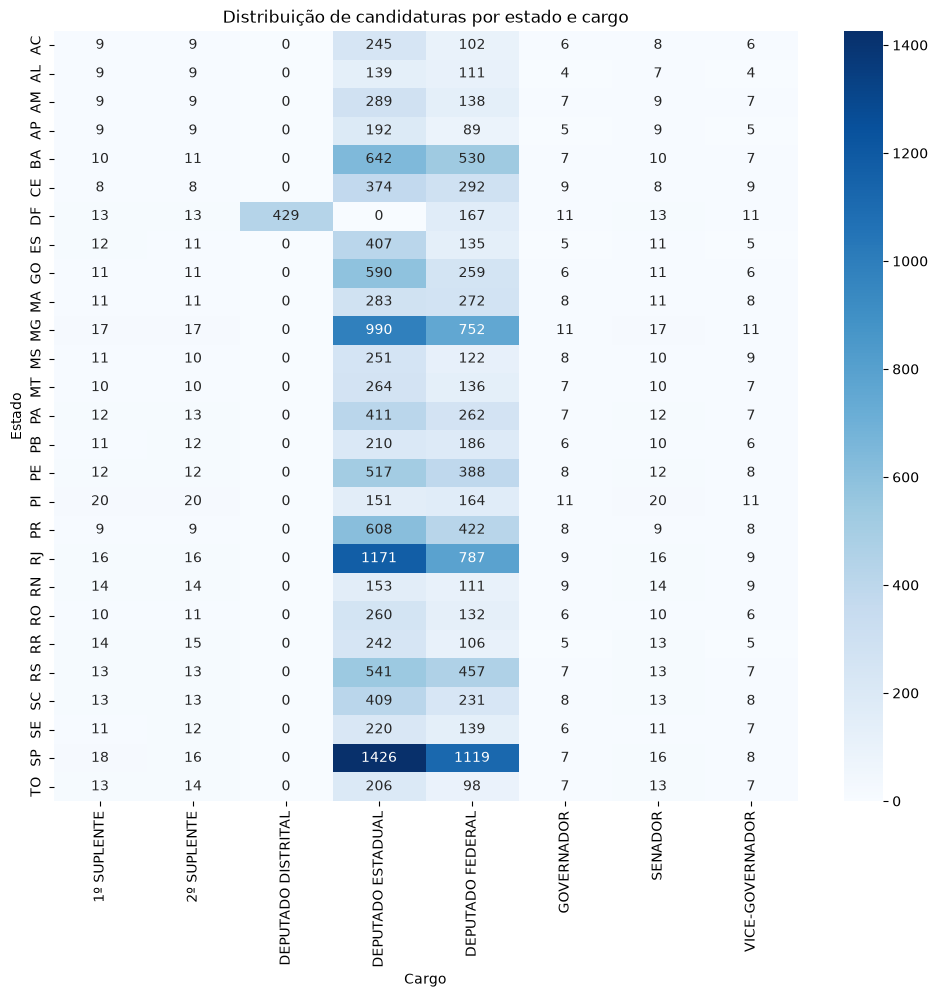

In [108]:
matriz_estado_cargo = (
    estado_cargo
    .pivot(
        index="estado",
        columns="cargo",
        values="Quantidade"
    )
    .fillna(0)
)


plt.figure(figsize=(12,10))

sns.heatmap(
    matriz_estado_cargo,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Distribuição de candidaturas por estado e cargo")
plt.xlabel("Cargo")
plt.ylabel("Estado")

plt.show()

In [ ]:
## 6.1 Distribuição de candidaturas por estado e cargo

A análise cruzada entre estado e cargo evidencia diferenças importantes na distribuição das candidaturas entre as unidades federativas.

Observa-se que os cargos proporcionais, especialmente Deputado Estadual e Deputado Federal, apresentam maior concentração de candidatos nos estados com maior participação eleitoral. São Paulo, Rio de Janeiro e Minas Gerais apresentam os maiores volumes absolutos de candidaturas para esses cargos.

Em contraste, os cargos majoritários, como Governador, Senador e Vice-Governador, apresentam distribuição mais uniforme entre os estados, devido às limitações naturais do processo eleitoral para essas funções.

Os resultados indicam que a variação regional das candidaturas está principalmente associada aos cargos proporcionais, enquanto os cargos majoritários possuem comportamento mais homogêneo entre as unidades federativas.

In [109]:
analise_estado_partido = (
    fato_candidatura
    .merge(
        dim_estado[
            [
                "id_estado",
                "estado"
            ]
        ],
        on="id_estado",
        how="left"
    )
    .merge(
        dim_partido[
            [
                "id_partido",
                "partido"
            ]
        ],
        on="id_partido",
        how="left"
    )
)

analise_estado_partido.head()

,SQ_CANDIDATO,id_partido,id_cargo,id_estado,ANO_ELEICAO,situacao_final,estado,partido
0,260002551550,3,5,25.0,2026,Não informado,SE,PDT
1,90002547105,24,6,9.0,2026,Não informado,GO,PSDB
2,90002547109,24,6,9.0,2026,Não informado,GO,PSDB
3,250002553062,16,3,26.0,2026,Não informado,SP,PCO
4,40002551283,8,5,3.0,2026,Não informado,AM,REDE


In [110]:
analise_estado_partido.shape

(20695, 8)

In [111]:
estado_partido = (
    analise_estado_partido
    .groupby(
        [
            "estado",
            "partido"
        ]
    )
    .size()
    .reset_index(name="Quantidade")
)

estado_partido.head()

,estado,partido,Quantidade
0,AC,AGIR,8
1,AC,AVANTE,4
2,AC,CIDADANIA,8
3,AC,DC,3
4,AC,DEMOCRATA,3


In [112]:
matriz_estado_partido = (
    estado_partido
    .pivot(
        index="estado",
        columns="partido",
        values="Quantidade"
    )
    .fillna(0)
)

matriz_estado_partido.head()

partido,AGIR,AVANTE,CIDADANIA,DC,DEMOCRATA,MDB,MISSÃO,MOBILIZA,NOVO,PCB,PCDOB,PCO,PDT,PL,PODE,PP,PRD,PRTB,PSB,PSD,PSDB,PSOL,PSTU,PT,PV,REDE,REPUBLICANOS,SOLIDARIEDADE,UNIÃO,UP
estado,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AC,8.0,4.0,8.0,3.0,3.0,29.0,0.0,0.0,31.0,2.0,5.0,0.0,24.0,30.0,33.0,22.0,9.0,0.0,13.0,23.0,26.0,9.0,0.0,20.0,5.0,3.0,35.0,23.0,17.0,0.0
AL,0.0,6.0,0.0,15.0,10.0,48.0,9.0,0.0,6.0,0.0,4.0,0.0,1.0,24.0,0.0,18.0,22.0,0.0,0.0,11.0,38.0,0.0,0.0,20.0,7.0,0.0,3.0,23.0,9.0,9.0
AM,25.0,34.0,0.0,12.0,0.0,36.0,9.0,7.0,34.0,0.0,4.0,0.0,32.0,39.0,34.0,6.0,0.0,0.0,18.0,36.0,3.0,19.0,9.0,21.0,0.0,14.0,33.0,8.0,33.0,2.0
AP,1.0,0.0,0.0,17.0,0.0,24.0,5.0,0.0,23.0,0.0,6.0,9.0,25.0,33.0,37.0,4.0,0.0,0.0,3.0,33.0,0.0,3.0,2.0,14.0,7.0,20.0,26.0,0.0,26.0,0.0
BA,21.0,85.0,15.0,46.0,0.0,98.0,24.0,53.0,35.0,0.0,13.0,5.0,91.0,100.0,17.0,27.0,13.0,0.0,57.0,42.0,90.0,73.0,0.0,54.0,21.0,20.0,109.0,25.0,74.0,9.0


In [113]:
top_partidos = (
    analise_estado_partido
    .groupby("partido")
    .size()
    .sort_values(
        ascending=False
    )
    .head(15)
    .index
)

In [114]:
matriz_estado_partido_top = (
    estado_partido[
        estado_partido["partido"].isin(top_partidos)
    ]
    .pivot(
        index="estado",
        columns="partido",
        values="Quantidade"
    )
    .fillna(0)
)

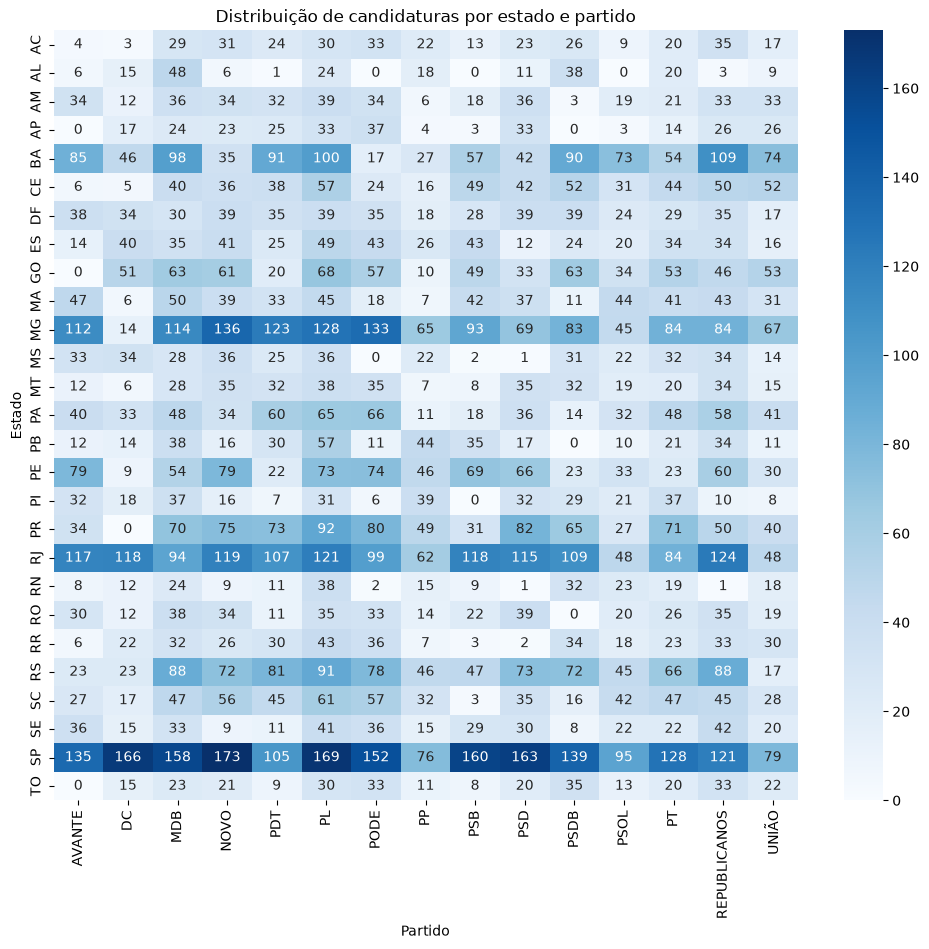

In [115]:
plt.figure(figsize=(12,10))

sns.heatmap(
    matriz_estado_partido_top,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title(
    "Distribuição de candidaturas por estado e partido"
)

plt.xlabel("Partido")
plt.ylabel("Estado")

plt.show()

In [ ]:
## 6.2 Distribuição de candidaturas por estado e partido

A análise cruzada entre estado e partido permite avaliar a distribuição regional das principais legendas participantes do processo eleitoral.

Observa-se que os partidos com maior número absoluto de candidaturas apresentam presença distribuída entre diferentes unidades federativas, destacando-se PL, MDB, Republicanos, NOVO e demais legendas com atuação nacional.

Os estados com maior volume eleitoral, como São Paulo, Rio de Janeiro e Minas Gerais, concentram os maiores números de candidaturas para diferentes partidos, indicando maior competitividade e diversidade partidária.

Apesar da presença nacional das principais legendas, o comportamento regional evidencia diferenças na participação partidária entre os estados, indicando que a distribuição das candidaturas não ocorre de forma totalmente uniforme.

In [116]:
analise_estado_genero = (
    fato_candidatura
    .merge(
        dim_estado[
            [
                "id_estado",
                "estado"
            ]
        ],
        on="id_estado",
        how="left"
    )
    .merge(
        dim_candidato[
            [
                "SQ_CANDIDATO",
                "genero"
            ]
        ],
        on="SQ_CANDIDATO",
        how="left"
    )
)

analise_estado_genero.head()

,SQ_CANDIDATO,id_partido,id_cargo,id_estado,ANO_ELEICAO,situacao_final,estado,genero
0,260002551550,3,5,25.0,2026,Não informado,SE,MASCULINO
1,90002547105,24,6,9.0,2026,Não informado,GO,FEMININO
2,90002547109,24,6,9.0,2026,Não informado,GO,MASCULINO
3,250002553062,16,3,26.0,2026,Não informado,SP,FEMININO
4,40002551283,8,5,3.0,2026,Não informado,AM,MASCULINO


In [117]:
analise_estado_genero.shape

(20695, 8)

In [118]:
estado_genero = (
    analise_estado_genero
    .groupby(
        [
            "estado",
            "genero"
        ]
    )
    .size()
    .reset_index(name="Quantidade")
)

estado_genero.head()

,estado,genero,Quantidade
0,AC,FEMININO,141
1,AC,MASCULINO,244
2,AL,FEMININO,102
3,AL,MASCULINO,181
4,AM,FEMININO,165


In [119]:
estado_genero["Percentual"] = (
    estado_genero["Quantidade"]
    /
    estado_genero.groupby("estado")["Quantidade"]
    .transform("sum")
    * 100
)

estado_genero.head()

,estado,genero,Quantidade,Percentual
0,AC,FEMININO,141,36.623377
1,AC,MASCULINO,244,63.376623
2,AL,FEMININO,102,36.042403
3,AL,MASCULINO,181,63.957597
4,AM,FEMININO,165,35.256410


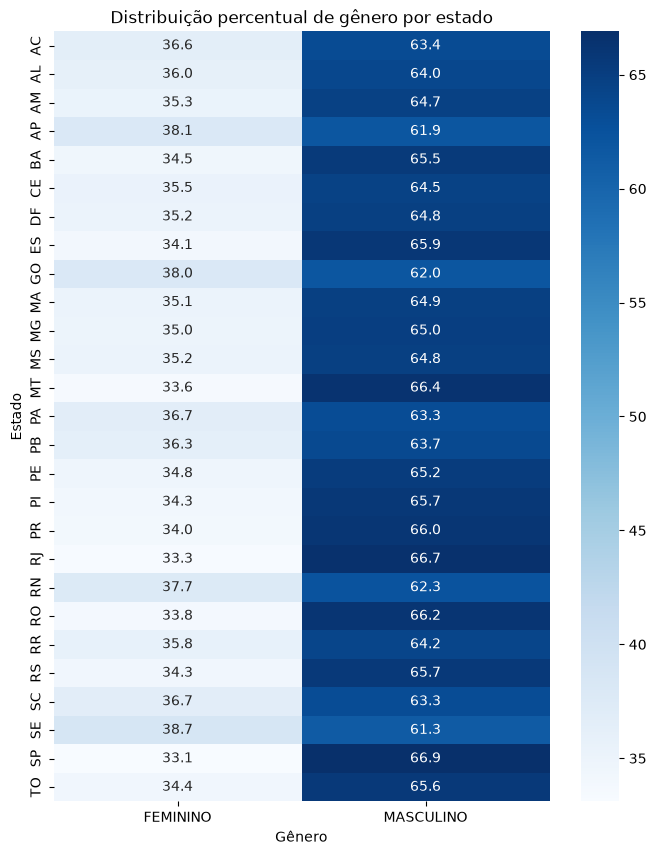

In [120]:
matriz_estado_genero = (
    estado_genero
    .pivot(
        index="estado",
        columns="genero",
        values="Percentual"
    )
)

plt.figure(figsize=(8,10))

sns.heatmap(
    matriz_estado_genero,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title(
    "Distribuição percentual de gênero por estado"
)

plt.xlabel("Gênero")
plt.ylabel("Estado")

plt.show()

In [ ]:
## 6.3 Distribuição de gênero por estado

A análise da distribuição de gênero entre os estados permite observar se existem diferenças regionais na composição das candidaturas.

Os resultados demonstram uma predominância masculina em todas as unidades federativas analisadas. A participação feminina varia aproximadamente entre 33% e 39%, enquanto candidatos do gênero masculino representam entre 61% e 67% das candidaturas.

Os maiores percentuais de participação feminina foram observados em estados como Sergipe (38,7%), Amapá (38,1%) e Goiás (38,0%). Por outro lado, estados com grande volume eleitoral, como São Paulo (33,1%) e Rio de Janeiro (33,3%), apresentaram menores proporções relativas de candidaturas femininas.

Apesar das diferenças entre estados, observa-se um padrão nacional semelhante, indicando que a desigualdade de gênero na composição das candidaturas permanece distribuída de maneira relativamente uniforme entre as unidades federativas.

In [121]:
analise_idade_cargo = (
    fato_candidatura
    .merge(
        dim_candidato[
            [
                "SQ_CANDIDATO",
                "idade"
            ]
        ],
        on="SQ_CANDIDATO",
        how="left"
    )
    .merge(
        dim_cargo[
            [
                "id_cargo",
                "cargo"
            ]
        ],
        on="id_cargo",
        how="left"
    )
)

analise_idade_cargo.head()

,SQ_CANDIDATO,id_partido,id_cargo,id_estado,ANO_ELEICAO,situacao_final,idade,cargo
0,260002551550,3,5,25.0,2026,Não informado,65,SENADOR
1,90002547105,24,6,9.0,2026,Não informado,61,DEPUTADO FEDERAL
2,90002547109,24,6,9.0,2026,Não informado,72,DEPUTADO FEDERAL
3,250002553062,16,3,26.0,2026,Não informado,31,GOVERNADOR
4,40002551283,8,5,3.0,2026,Não informado,44,SENADOR


In [122]:
analise_idade_cargo.shape

(20695, 8)

In [123]:
idade_cargo = (
    analise_idade_cargo
    .groupby("cargo")["idade"]
    .agg(
        Media="mean",
        Mediana="median",
        Minima="min",
        Maxima="max",
        Quantidade="count"
    )
    .sort_values("Media")
    .reset_index()
)

idade_cargo

,cargo,Media,Mediana,Minima,Maxima,Quantidade
0,DEPUTADO DISTRITAL,47.993007,48.0,22,87,429
1,DEPUTADO FEDERAL,48.763981,48.0,19,89,7707
2,DEPUTADO ESTADUAL,49.102225,49.0,19,92,11191
3,GOVERNADOR,50.595960,50.0,30,74,198
4,VICE-GOVERNADOR,51.039801,50.0,30,82,201
5,1º SUPLENTE,53.424615,52.0,33,89,325
6,2º SUPLENTE,53.600610,52.0,31,86,328
7,SENADOR,55.389241,56.0,35,92,316


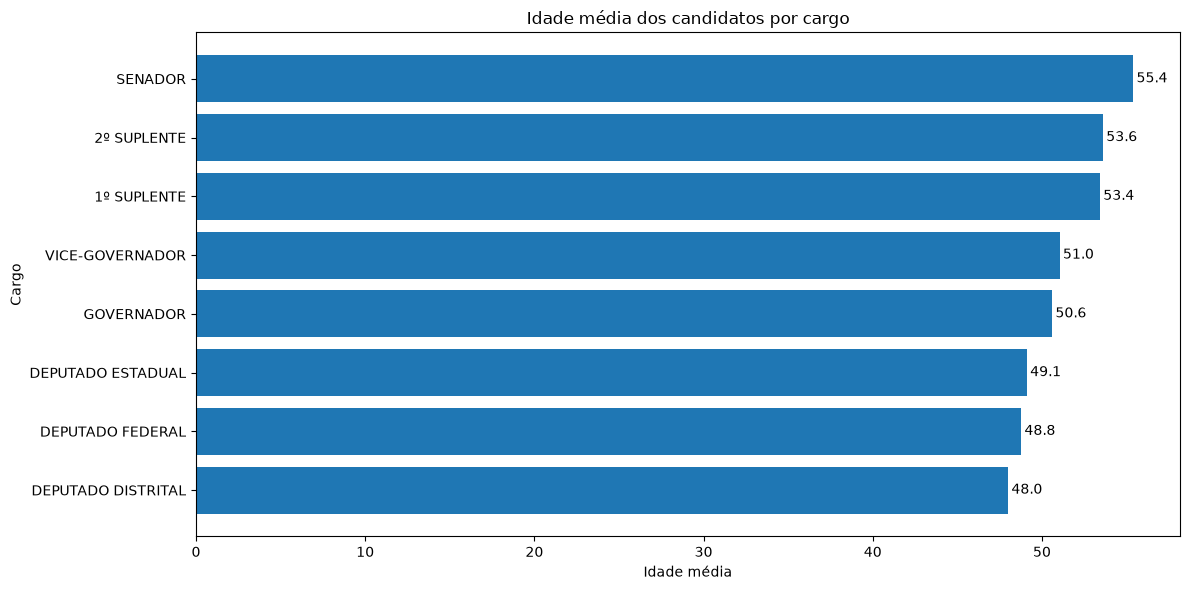

In [124]:
plt.figure(figsize=(12, 6))

plt.barh(
    idade_cargo["cargo"],
    idade_cargo["Media"]
)

plt.xlabel("Idade média")
plt.ylabel("Cargo")
plt.title("Idade média dos candidatos por cargo")

for i, valor in enumerate(idade_cargo["Media"]):
    plt.text(
        valor + 0.2,
        i,
        f"{valor:.1f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
## 6.4 Distribuição de idade por cargo

A análise da idade dos candidatos permite identificar diferenças no perfil etário associado aos diferentes cargos disputados.

Os resultados indicam que os candidatos ao cargo de Senador apresentam a maior idade média, com aproximadamente 55,4 anos, seguidos pelos candidatos a 2º Suplente (53,6 anos) e 1º Suplente (53,4 anos). Entre os cargos majoritários, as médias observadas foram de 51,0 anos para Vice-Governador e 50,6 anos para Governador.

Os cargos proporcionais apresentaram médias ligeiramente menores, com 49,1 anos para Deputado Estadual, 48,8 anos para Deputado Federal e 48,0 anos para Deputado Distrital.

De modo geral, observa-se uma diferença etária entre os cargos, com maior idade média entre candidatos a Senado e cargos de suplência, enquanto os cargos de deputado apresentam as menores médias. Esse resultado sugere diferenças no perfil etário dos candidatos conforme o tipo de cargo disputado.

In [125]:
idade_genero = (
    analise_idade_cargo
    .merge(
        dim_candidato[
            [
                "SQ_CANDIDATO",
                "genero"
            ]
        ],
        on="SQ_CANDIDATO",
        how="left"
    )
    .groupby("genero")["idade"]
    .agg(
        Media="mean",
        Mediana="median",
        Minima="min",
        Maxima="max",
        Quantidade="count"
    )
    .reset_index()
)

idade_genero

,genero,Media,Mediana,Minima,Maxima,Quantidade
0,FEMININO,47.751038,47.0,19,92,7222
1,MASCULINO,50.009797,49.0,20,92,13473


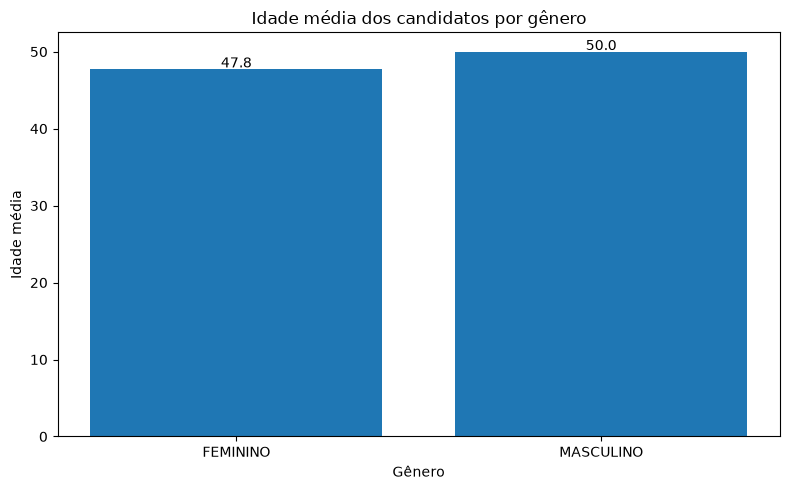

In [126]:
plt.figure(figsize=(8, 5))

plt.bar(
    idade_genero["genero"],
    idade_genero["Media"]
)

plt.xlabel("Gênero")
plt.ylabel("Idade média")
plt.title("Idade média dos candidatos por gênero")

for i, valor in enumerate(idade_genero["Media"]):
    plt.text(
        i,
        valor + 0.2,
        f"{valor:.1f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
## 6.5 Distribuição de idade por gênero

A análise da idade dos candidatos segundo o gênero permite identificar diferenças no perfil etário das candidaturas.

Os resultados indicam que os candidatos do gênero masculino apresentam idade média de aproximadamente 50,0 anos, enquanto as candidatas do gênero feminino apresentam média de 47,8 anos. A diferença observada é de aproximadamente 2,3 anos.

A mediana também apresenta diferença entre os grupos, correspondendo a 49 anos entre os candidatos masculinos e 47 anos entre as candidatas femininas. As idades máximas são iguais nos dois grupos, atingindo 92 anos.

De forma geral, os resultados indicam que, no conjunto analisado, as candidaturas masculinas apresentam idade média ligeiramente superior às candidaturas femininas.

In [127]:
analise_estado_escolaridade = (
    fato_candidatura
    .merge(
        dim_candidato[
            [
                "SQ_CANDIDATO",
                "escolaridade"
            ]
        ],
        on="SQ_CANDIDATO",
        how="left"
    )
    .merge(
        dim_estado[
            [
                "id_estado",
                "estado"
            ]
        ],
        on="id_estado",
        how="left"
    )
)

analise_estado_escolaridade.head()

,SQ_CANDIDATO,id_partido,id_cargo,id_estado,ANO_ELEICAO,situacao_final,escolaridade,estado
0,260002551550,3,5,25.0,2026,Não informado,SUPERIOR INCOMPLETO,SE
1,90002547105,24,6,9.0,2026,Não informado,SUPERIOR COMPLETO,GO
2,90002547109,24,6,9.0,2026,Não informado,SUPERIOR COMPLETO,GO
3,250002553062,16,3,26.0,2026,Não informado,SUPERIOR INCOMPLETO,SP
4,40002551283,8,5,3.0,2026,Não informado,SUPERIOR COMPLETO,AM


In [128]:
analise_estado_escolaridade.shape

(20695, 8)

In [129]:
estado_escolaridade = (
    analise_estado_escolaridade
    .groupby(
        [
            "estado",
            "escolaridade"
        ]
    )
    .size()
    .reset_index(name="Quantidade")
)

estado_escolaridade.head()

,estado,escolaridade,Quantidade
0,AC,ENSINO FUNDAMENTAL COMPLETO,15
1,AC,ENSINO FUNDAMENTAL INCOMPLETO,19
2,AC,ENSINO MÉDIO COMPLETO,87
3,AC,ENSINO MÉDIO INCOMPLETO,16
4,AC,LÊ E ESCREVE,3


In [130]:
estado_escolaridade["Percentual"] = (
    estado_escolaridade["Quantidade"]
    /
    estado_escolaridade.groupby("estado")["Quantidade"].transform("sum")
    * 100
)

estado_escolaridade.head()

,estado,escolaridade,Quantidade,Percentual
0,AC,ENSINO FUNDAMENTAL COMPLETO,15,3.896104
1,AC,ENSINO FUNDAMENTAL INCOMPLETO,19,4.935065
2,AC,ENSINO MÉDIO COMPLETO,87,22.597403
3,AC,ENSINO MÉDIO INCOMPLETO,16,4.155844
4,AC,LÊ E ESCREVE,3,0.779221


In [131]:
estado_escolaridade.groupby("estado")["Percentual"].sum().head()

estado
AC    100.0
AL    100.0
AM    100.0
AP    100.0
BA    100.0
Name: Percentual, dtype: float64

In [132]:
matriz_estado_escolaridade = (
    estado_escolaridade
    .pivot(
        index="estado",
        columns="escolaridade",
        values="Percentual"
    )
    .fillna(0)
)

matriz_estado_escolaridade

escolaridade,ENSINO FUNDAMENTAL COMPLETO,ENSINO FUNDAMENTAL INCOMPLETO,ENSINO MÉDIO COMPLETO,ENSINO MÉDIO INCOMPLETO,LÊ E ESCREVE,SUPERIOR COMPLETO,SUPERIOR INCOMPLETO
estado,,,,,,,
AC,3.896104,4.935065,22.597403,4.155844,0.779221,55.324675,8.311688
AL,1.766784,2.473498,16.254417,2.826855,0.706714,66.077739,9.893993
AM,2.136752,1.495726,23.504274,1.282051,1.282051,61.538462,8.760684
AP,0.628931,0.628931,16.352201,2.201258,0.628931,72.955975,6.603774
BA,2.465078,2.136401,27.198028,3.204601,0.328677,52.670501,11.996713
CE,2.683616,3.813559,21.892655,2.683616,0.423729,56.638418,11.864407
DF,1.217656,2.130898,12.480974,1.826484,0.000000,73.515982,8.828006
ES,1.365188,1.877133,25.426621,2.901024,0.000000,58.361775,10.068259
GO,2.237136,3.467562,22.818792,5.592841,0.447427,55.369128,10.067114


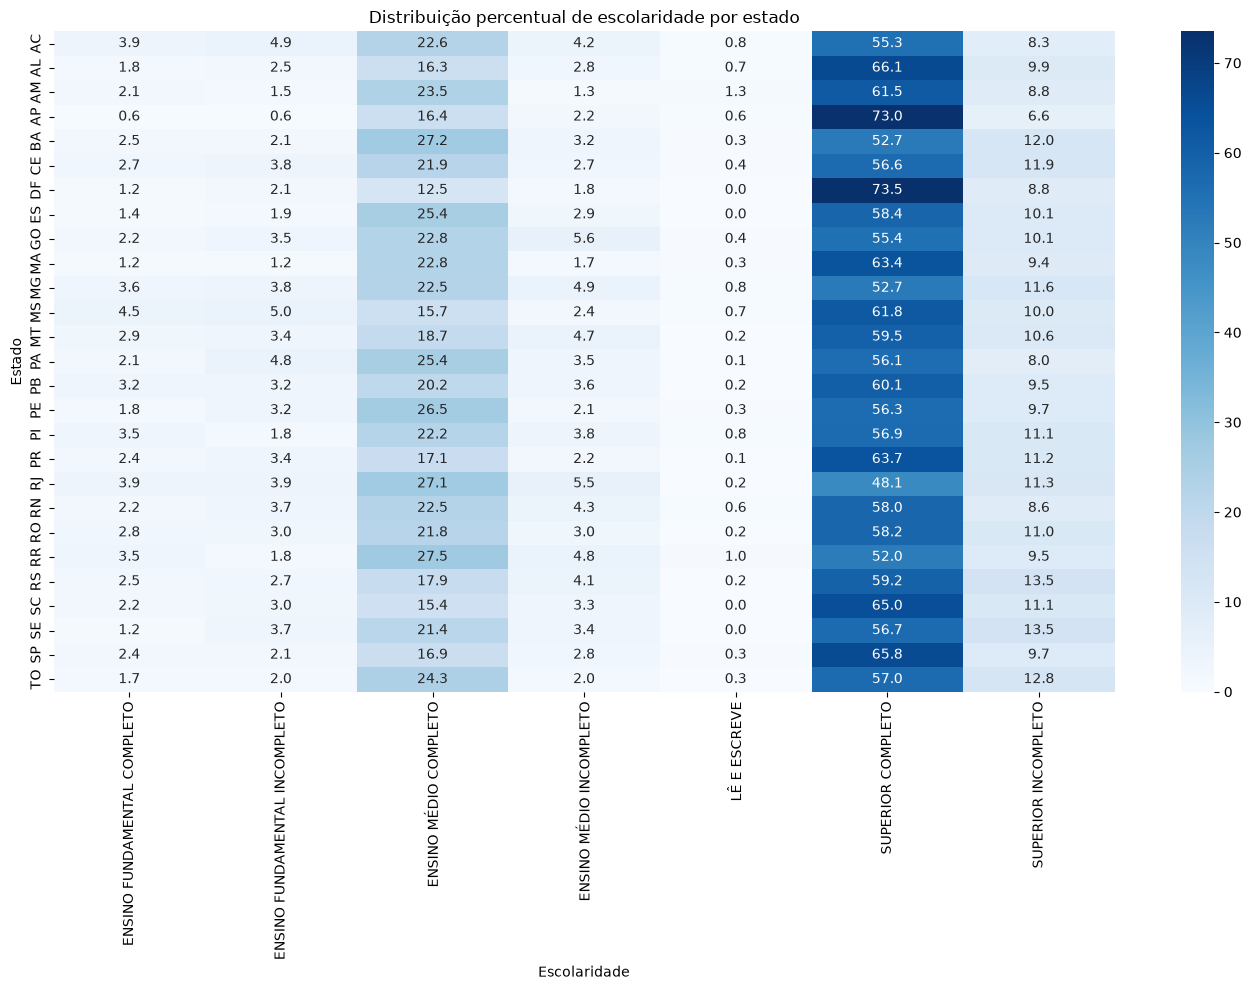

In [133]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    matriz_estado_escolaridade,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Distribuição percentual de escolaridade por estado")
plt.xlabel("Escolaridade")
plt.ylabel("Estado")

plt.tight_layout()
plt.show()

In [134]:
analise_genero_escolaridade = (
    fato_candidatura
    .merge(
        dim_candidato[
            [
                "SQ_CANDIDATO",
                "genero",
                "escolaridade"
            ]
        ],
        on="SQ_CANDIDATO",
        how="left"
    )
)

analise_genero_escolaridade.head()

,SQ_CANDIDATO,id_partido,id_cargo,id_estado,ANO_ELEICAO,situacao_final,genero,escolaridade
0,260002551550,3,5,25.0,2026,Não informado,MASCULINO,SUPERIOR INCOMPLETO
1,90002547105,24,6,9.0,2026,Não informado,FEMININO,SUPERIOR COMPLETO
2,90002547109,24,6,9.0,2026,Não informado,MASCULINO,SUPERIOR COMPLETO
3,250002553062,16,3,26.0,2026,Não informado,FEMININO,SUPERIOR INCOMPLETO
4,40002551283,8,5,3.0,2026,Não informado,MASCULINO,SUPERIOR COMPLETO


In [135]:
analise_genero_escolaridade.shape

(20695, 8)

In [136]:
genero_escolaridade = (
    analise_genero_escolaridade
    .groupby(
        [
            "genero",
            "escolaridade"
        ]
    )
    .size()
    .reset_index(name="Quantidade")
)

genero_escolaridade.head(10)

,genero,escolaridade,Quantidade
0,FEMININO,ENSINO FUNDAMENTAL COMPLETO,151
1,FEMININO,ENSINO FUNDAMENTAL INCOMPLETO,182
2,FEMININO,ENSINO MÉDIO COMPLETO,1525
3,FEMININO,ENSINO MÉDIO INCOMPLETO,231
4,FEMININO,LÊ E ESCREVE,24
5,FEMININO,SUPERIOR COMPLETO,4337
6,FEMININO,SUPERIOR INCOMPLETO,772
7,MASCULINO,ENSINO FUNDAMENTAL COMPLETO,384
8,MASCULINO,ENSINO FUNDAMENTAL INCOMPLETO,433
9,MASCULINO,ENSINO MÉDIO COMPLETO,2921


In [137]:
genero_escolaridade["Percentual"] = (
    genero_escolaridade["Quantidade"]
    /
    genero_escolaridade.groupby("genero")["Quantidade"].transform("sum")
    * 100
)

genero_escolaridade.head(10)

,genero,escolaridade,Quantidade,Percentual
0,FEMININO,ENSINO FUNDAMENTAL COMPLETO,151,2.090834
1,FEMININO,ENSINO FUNDAMENTAL INCOMPLETO,182,2.520078
2,FEMININO,ENSINO MÉDIO COMPLETO,1525,21.116034
3,FEMININO,ENSINO MÉDIO INCOMPLETO,231,3.198560
4,FEMININO,LÊ E ESCREVE,24,0.332318
5,FEMININO,SUPERIOR COMPLETO,4337,60.052617
6,FEMININO,SUPERIOR INCOMPLETO,772,10.689560
7,MASCULINO,ENSINO FUNDAMENTAL COMPLETO,384,2.850145
8,MASCULINO,ENSINO FUNDAMENTAL INCOMPLETO,433,3.213835
9,MASCULINO,ENSINO MÉDIO COMPLETO,2921,21.680398


In [138]:
genero_escolaridade.groupby("genero")["Percentual"].sum()

genero
FEMININO     100.0
MASCULINO    100.0
Name: Percentual, dtype: float64

In [141]:
matriz_genero_escolaridade = (
    genero_escolaridade
    .pivot(
        index="genero",
        columns="escolaridade",
        values="Percentual"
    )
    .fillna(0)
)

matriz_genero_escolaridade

escolaridade,ENSINO FUNDAMENTAL COMPLETO,ENSINO FUNDAMENTAL INCOMPLETO,ENSINO MÉDIO COMPLETO,ENSINO MÉDIO INCOMPLETO,LÊ E ESCREVE,SUPERIOR COMPLETO,SUPERIOR INCOMPLETO
genero,,,,,,,
FEMININO,2.090834,2.520078,21.116034,3.198560,0.332318,60.052617,10.689560
MASCULINO,2.850145,3.213835,21.680398,3.644326,0.378535,57.722853,10.509909


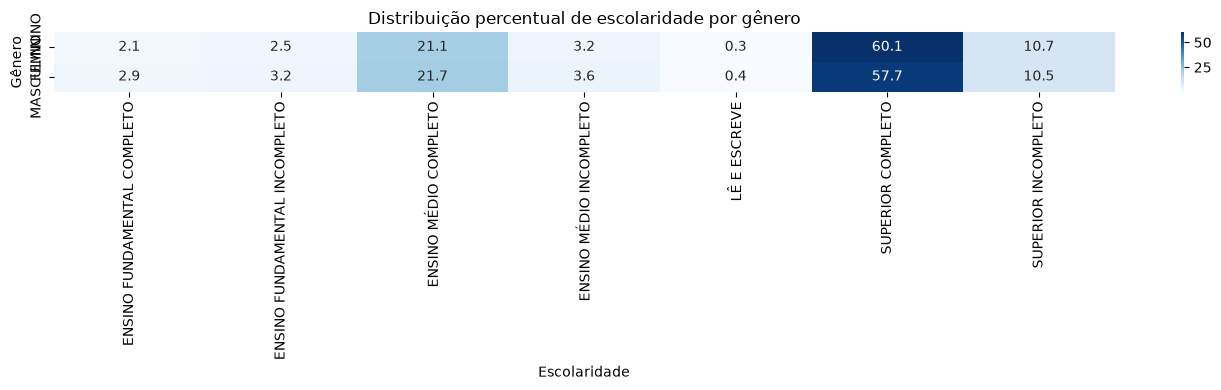

In [142]:
plt.figure(figsize=(14, 4))

sns.heatmap(
    matriz_genero_escolaridade,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Distribuição percentual de escolaridade por gênero")
plt.xlabel("Escolaridade")
plt.ylabel("Gênero")

plt.tight_layout()
plt.show()

In [ ]:
## 6.7 Distribuição de escolaridade por gênero

A análise da distribuição de escolaridade por gênero permite verificar se existem diferenças na formação educacional dos candidatos entre os grupos feminino e masculino.

Os resultados indicam uma composição relativamente semelhante entre os dois gêneros. O ensino superior completo representa 60,1% das candidatas do gênero feminino e 57,7% dos candidatos do gênero masculino, constituindo a principal categoria de escolaridade em ambos os grupos.

O ensino médio completo corresponde a 21,1% das candidatas e 21,7% dos candidatos, enquanto o ensino superior incompleto representa 10,7% e 10,5%, respectivamente. As demais categorias apresentam participações inferiores a 5% em ambos os grupos.

De modo geral, observa-se que a distribuição da escolaridade apresenta diferenças relativamente pequenas entre os gêneros, com predominância do ensino superior completo nos dois grupos. 